In [1]:
import xarray as xr
import analyze_precip as ap
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs
import seaborn as sns
import importlib
import cftime
from scipy.stats import skew
import datetime
import os
import fnmatch
import time
from datetime import timedelta
import pickle

import track_TCs
import TC_analysis

## Auxiliary functions

### get LMI dfs

In [2]:
def risplit_dfs(track_df):
    # calculate 24-hour acceleration
    track_df['acceleration_24'] = track_df.groupby('storm_id')['max_wind'].diff(periods=4)
    
    # identify RI/non-RI storm ids
    catch_df = track_df[track_df['acceleration_24'] > 18] # RI: +18 m/s within 24 hours
    ristorms = catch_df['storm_id'].unique()
    
    nonstorms = []
    for k in track_df['storm_id'].unique():
        if k in ristorms:
            continue
        else:
            nonstorms.append(k)

    assert len(track_df['storm_id'].unique()) == len(ristorms) + len(nonstorms), f"error with ristorm and non-ristorm length"
    
    # create RI/non-RI storm dataframes
    ri_df = track_df[track_df['storm_id'].isin(ristorms)]
    ri_df['max_wind_kts'] = ri_df['max_wind']*1.94384
    
    nonri_df = track_df[track_df['storm_id'].isin(nonstorms)]
    nonri_df['max_wind_kts'] = nonri_df['max_wind']*1.94384

    return ri_df, nonri_df

In [3]:
def get_LMI_dfs(track_df):
    ri_df, nonri_df = risplit_dfs(track_df)

    lmi_ri_df = ri_df.groupby('storm_id')['max_wind'].max().to_frame()
    lmi_nonri_df = nonri_df.groupby('storm_id')['max_wind'].max().to_frame()

    return lmi_ri_df, lmi_nonri_df

### plot

In [4]:
def plot_xrda(dataarray, title, robust, vmin: int=None, vmax: int=None, cmap: str="viridis"):
    fig, ax = plt.subplots(figsize=(8,3), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    
    if robust == 0:
        dataarray.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax) # robust=True will get reduce noise beyond stdev thresh
    elif robust == 1:
        dataarray.plot(ax=ax, transform=ccrs.PlateCarree(), robust=True, cmap=cmap, vmin=vmin, vmax=vmax) # robust=True will get reduce noise beyond stdev thresh
    ax.gridlines(draw_labels=['bottom', 'left'], ls=':')
    ax.coastlines()
    ax.set_title(f"{title}")

In [5]:
def plot_snapshot(snapshot, title, metatext, robust: int=0, vmin: int=None, vmax: int=None, cmap: str="viridis"):
    fig, ax = plt.subplots(dpi=300)
    snapshot.plot(ax=ax, cmap=cmap)
    ax.set_title(title)
    ax.text(0.1, 0.1, metatext)

### basin, Hseason, density filtering

In [ ]:
def basinfilter(xarray, basin2mask):
    basinmask_path = "BASIN_MASK_PATH"
    basin_ds = xr.open_dataset(basinmask_path).load()
    
    if basin2mask == 'tropics': # latitude filter
        xarray = xr.concat([xarray.sel(lat=slice(-30,-10)), xarray.sel(lat=slice(10,30))], dim="lat")
    elif basin2mask != 'global':
        x = basin_ds.where(basin_ds[basin2mask] == 1, drop=True)[basin2mask] #stores basin coordinates

        maxlat = max(x['grid_yt']).item()
        minlat = min(x['grid_yt']).item()
        maxlon = max(x['grid_xt']).item()
        minlon = min(x['grid_xt']).item()

        if 'lon' in xarray.coords:
            xarray = xarray.where((xarray['lat'] >= minlat) & (xarray['lat'] <= maxlat), drop=True) #filter latitude
            xarray = xarray.where((xarray['lon'] >= minlon) & (xarray['lon'] <= maxlon), drop=True) #filter longitude
        else:
            print(f"Coordinates not found in xarray.")
        
    return xarray

In [ ]:
def TCdensity(GW, year_range, PIx_da):
    global TCdensity_xr
    
    # get experiment names and dictionary of xarrays
    from pathlib import Path
    
    experiment_path = 'EXPERIMENT_PATH'
    
    experiments = []
    if GW == 1:
        target_files = list(Path(experiment_path).glob('*DUMMY_STRING*'))
        for file in target_files:
            experiments.append(str(file)[-29:])
    elif GW == 0:
        target_files = list(Path(experiment_path).glob('*DUMMY_STRINGn*'))
        for file in target_files:
            experiments.append(str(file)[-39:])

    # experiments already gathered in prev cell
    model_name = 'AM2.5C360'
    experiment_name = experiments
        #en06-en10 (experiments[1-2, 5-7]) do not work for some reason -> all GW = 0
    
    # return dictionary[model_name][experiment_name] of TC density
    TCdensity = TC_analysis.TC_density(model_names=model_name, experiment_names=experiment_name, year_range=year_range)
    
    listof_TCdensities = []
    
    # combine all ensemble density outputs
    for exp in experiment_name:
        TMP = TCdensity[model_name][exp]
        
        # convert dictionary to dataframe with same dims for xarray
        TCdensity_xr = xr.DataArray(data=TMP.values,
                                       coords={'lat': (['lat'], TMP.index),
                                               'lon': (['lon'], TMP.columns)},
                                       dims=['lat', 'lon'])
        
        TCdensity_xr = TCdensity_xr.sel(lat=slice(PIx_da.lat.min(), PIx_da.lat.max()))
        # Interpolate to GCM native resolution
        TCdensity_xr = TCdensity_xr.interp(lon=PIx_da.lon, lat=PIx_da.lat).fillna(0)
        listof_TCdensities.append(TCdensity_xr) # append xarray to list for concatenation
    
    TCdensity_xr = xr.concat(listof_TCdensities, dim='exp')
    density = TCdensity_xr.mean(dim='exp')
    
    #normDensity = ((TCdensity_xr - TCdensity_xr.min()) / (TCdensity_xr.max() - TCdensity_xr.min())) #normalize (0,1) for matrix multiplication
    #normDensity = normDensity+1 #normalize (1,2) for matrix multiplication

    return density

In [ ]:
'''
filter that returns dataarray with only points from hurricane season

NH: August-October
SH: April-December
'''
def hurricane_season(xarray):
    north_da = xarray.where((xarray['lat'] > 0) & (xarray['time'].dt.month >= 8) & (xarray['time'].dt.month <= 10), drop=True)
    south_da = xarray.where((xarray['lat'] < 0) & (xarray['time'].dt.month >= 4) & (xarray['time'].dt.month <= 12), drop=True)
    filtered = xr.concat([north_da, south_da], dim="time")

    #plot_xrda(filtered.mean(dim='time'), "hurricane season filter: filtered", 1) # print for debugging
    
    return filtered

### datetime object conversions

In [9]:
'''
converts cftime.datetime (TC time) object into cftime.Julian (atmos GCM time) object
'''

def cftime_d2j(tracktime):
    return cftime.DatetimeJulian(tracktime.year, tracktime.month, tracktime.day, tracktime.hour, tracktime.minute, tracktime.second)

In [10]:
'''
converts cftime.Julian (atmos GCM time) object into cftime.datetime (TC times) object
'''

def cftime_j2d(gcmtimeJ):
    if (gcmtimeJ.month == 2) and (gcmtimeJ.day == 29): # manually convert leap year times
        return cftime.datetime(gcmtimeJ.year, 3, 1, gcmtimeJ.hour, gcmtimeJ.minute, gcmtimeJ.second, calendar='noleap')
    return cftime.datetime(gcmtimeJ.year, gcmtimeJ.month, gcmtimeJ.day, gcmtimeJ.hour, gcmtimeJ.minute, gcmtimeJ.second, calendar='noleap')

In [11]:
'''
returns track_df row nearest to given GCMtime for a storm
'''

def nearest_trackRow(gcmtimeJ, alltrack_df, storm_id):
    storm_df = alltrack_df[(alltrack_df['storm_id'] == storm_id)]
    gcmtime = cftime_j2d(gcmtimeJ)
    if gcmtime in storm_df['cftime'].values:
        row = storm_df[storm_df['cftime'] == gcmtime]
        return row
    else:
        raise ExceptionName("No matching time found between TC and GCM.")

### Data loading

#### load atmos data

In [ ]:
'''
returns xarray DataArray of atmospheric parameter for a given year & ennum
'''

def load_atmos_da(GW, year, ennum, param, printButton):
    global param_da
    if GW == 1:
        GWpath = "WARMING_MODEL_PATH"
    elif GW == 0:
        GWpath = "NONWARMING_MODEL_PATH"
    
    dataPath = f"ATMOSPHERE_DATA_PATH"
    atmos_ds = xr.open_dataset(dataPath)
    param_da = atmos_ds[param] # DataArray for specific atmospheric variable
    param_da = param_da.rename({"grid_xt": "lon", "grid_yt": "lat"})

    assert param_da['time'].size == 365 or param_da['time'].size == 366 # should be daily frequency
    
    # print for debugging
    if printButton == 1:
        plot_xrda(param_da.mean(dim='time'), f"{param} {year}", 1)

    return param_da

#### load track data

In [ ]:
'''
returns pandas DataFrame of simulated TC track for given decades using pre-loaded data for all ennums
'''

def load_mytrackdf(GW, decadeList):
    for index, decade in enumerate(decadeList):
        if GW == 0:
            filename = "NONWARMING_TC_TRACK_PATH"
        elif GW == 1:
            filename = "WARMING_TC_TRACK_PATH"

        dec_track_df = pd.read_pickle(filename)
        
        # adjust time column for jank years
        if decade[0] < 2000 and decade[0] >= 1900:
            offset_yrs = 100
        elif decade[0] < 1900 and decade[0] >= 1800:
            offset_yrs = 200
        else:
            offset_yrs = 0
        dec_track_df['adj_time'] = [
            t - pd.DateOffset(years=100) if (t.year <= 2005 and 1900 in decade) else t if (t.year <= 2005 and 1999 in decade) else t - pd.DateOffset(years=offset_yrs) if (t.year not in decade) else t for t in dec_track_df['time']
        ]
        dec_track_df['year'] = dec_track_df['adj_time'].dt.year
        dec_track_df['id'] = [f"{dec_track_df['year'].iloc[i]}-{dec_track_df['storm_id'].iloc[i][-4:]}" for i in dec_track_df.index]
        
        # concat columns
        if index == 0:
            track_df = dec_track_df
        else:
            track_df = pd.concat([track_df, dec_track_df])

    return track_df

In [ ]:
'''
returns pandas DataFrame of simulated TC track for given ennum model using GR's pre-loaded data
'''

def load_trackdf(GW, ennum):
    global trackfile
    if GW == 0:
        trackpath = "NONWARMING_TC_TRACK_PATH"
    elif GW == 1:
        trackpath = "WARMING_TC_TRACK_PATH"
    track_df = pd.read_pickle(trackpath)
    return track_df

#### process LMI

In [16]:
'''
returns pandas DataFrame of LMI of each TC (>= 33 m/s max windspeed) given model track data
'''

def trackLMI_filter(alltrack_df):
    # proccess LMI for this decade
    collect_dec_LMIdfs = []
    storm_ids = alltrack_df['storm_id'].unique() # get all storm ids
    print(f"{len(storm_ids)} unique storms found")
    lmi_df = alltrack_df.groupby('storm_id')['min_slp'].min().to_frame()
    #lmi_df = alltrack_df.groupby('storm_id')['max_wind'].max().to_frame()
    
    st_time = time.time()
    for i in storm_ids:
        LMIspeed = lmi_df.loc[i].item()
        #storm_df = alltrack_df.loc[(alltrack_df['storm_id'] == i) & (alltrack_df['max_wind'] == LMIspeed)]
        storm_df = alltrack_df.loc[(alltrack_df['storm_id'] == i) & (alltrack_df['min_slp'] == LMIspeed)]
        
        collect_dec_LMIdfs.append(storm_df)
    end_time = time.time()
    print(f"finished collecting LMI rows")
    print(f"time elapsed to filter LMI rows: {end_time-st_time}") # 190 sec for one ennum
    
    track_df = pd.concat(collect_dec_LMIdfs)
    print(f"finished concatenating")
    #track_df = track_df[track_df['max_wind'] >= 33] # filter for TC strength
    track_df = track_df[track_df['min_slp'] <= 990] # filter for TC strength
    track_df = track_df.reset_index()

    return track_df

### take snapshots

In [17]:
def pad_snapshot(snapshot, target_shape):
    pad_lat = target_shape[0] - snapshot.sizes['lat']
    pad_lon = target_shape[1] - snapshot.sizes['lon']

    pad_before_lat = pad_lat // 2
    pad_after_lat = pad_lat - pad_before_lat
    pad_before_lon = pad_lon // 2
    pad_after_lon = pad_lon - pad_before_lon

    padded = snapshot.pad(
        lat=(pad_before_lat, pad_after_lat),
        lon=(pad_before_lon, pad_after_lon),
        constant_values=np.nan
    )
    return padded

In [18]:
'''
"standardize_coord" projects given radiation data (rad_data) onto a standardized, storm-centered coordinate system.

Input:
  rad_data - CERES radiation parameter data
Output:
  new_arr - Xarray DataArray of CERES radiation data projected onto standardized coordinate system.
  
'''
def standardize_coord(atmos_da, width):
    # Define dimension names
    dim_name_X = 'lon'
    dim_name_Y = 'lat'

    lat_size = atmos_da['lat'].size
    lon_size = atmos_da['lon'].size
    
    # Define coordinate values so that it centers around storm
    longitude = np.linspace(-width, width, (2*width)+1)
    latitude = np.linspace(-width, width, (2*width)+1)
    
    new_arr = xr.DataArray(data=atmos_da,
                           dims=[dim_name_Y, dim_name_X],
                           coords={'lat': (['lat'], latitude),
                                   'lon': (['lon'], longitude)})
    
    return new_arr

In [ ]:
'''
"take_snapshot" takes a snapshot of CERES radiation data centered around the storm.

Input:
  lat - IBrACS storm latitude
  lon - IBrACS storm longitude
  rad_data - CERES radiation parameter data
Output:
  snapshot - 10x10 DataArray of CERES radiation data (centered around a storm).
  
'''

def take_snapshot(tarlat, tarlon, atmos_da):
    # create storm-centered snapshot window
    width = 30 # half width
    
    CERES_lon = atmos_da['lon'].values
    CERES_lat = atmos_da['lat'].values

    # find nearest matching latitude, longitude coordinate values in CERES dataset for given IBTrACS coordinates
    nr_lon_idx = (np.abs(CERES_lon - tarlon)).argmin()
    lon = CERES_lon[nr_lon_idx]
    
    nr_lat_idx = (np.abs(CERES_lat - tarlat)).argmin()
    lat = CERES_lat[nr_lat_idx]
    assert abs(tarlon-lon) < 0.3 and abs(tarlat-lat) < 0.3

    snapshot_raw = atmos_da.isel(lon=slice(nr_lon_idx-width,nr_lon_idx+width+1), lat=slice(nr_lat_idx-width,nr_lat_idx+width+1))

    if snapshot_raw['lon'].size != (width*2)+1 or snapshot_raw['lat'].size != (width*2)+1:
        snapshot_raw = pad_snapshot(snapshot_raw, target_shape=((width*2)+1, (width*2)+1))

    # project snapshot to storm-centered coordinates
    snapshot = standardize_coord(snapshot_raw, width)

    return snapshot

### gen & save database

In [20]:
'''
returns database of snapshots at/near LMI for GCM atmosphere param.
> alltrack_df = all DataFrame records for each storm
> track_df = LMI DataFrame records
> param = desired GCM atmosphere parameter
> timeDiff = # of hours before LMI for desired time differential snapshot
'''
def create_ssdatabase(alltrack_df, track_df, param, timeDiff):
    # store snapshots here
    database = []
    skipTally = 0 # count skipped snapshots
    adjTally = 0 # count snapshots taken before/after LMI
    
    # take atmos snapshots following TC track
    st_time = time.time()
    prevYear = track_df.iloc[0]['cftime'].year
    for index, row in track_df.iterrows():
        year = row['cftime'].year
        tracktimeJ = cftime_d2j(row['cftime'])
        
        if year != prevYear or index == 0: # only load new DataArray when new year starts
            ennum = row['storm_id'][-2:]
            atmos_yr = load_atmos_da(GW, year, ennum, param, 0) # DataArray of atmos for given year
            prevYear = year # reset year
    
        atmos_da = atmos_yr.sel(time=tracktimeJ, method='nearest')
        gcmtimeJ = atmos_da['time'].item() # find closest daily atmos timestamp

        if tracktimeJ != gcmtimeJ:
            # find nearest row in track data if it exists
            storm_df = alltrack_df[(alltrack_df['storm_id'] == row['storm_id'])]
            gcmtime = cftime_j2d(gcmtimeJ)
            if gcmtime in storm_df['cftime'].values:
                newRow = storm_df[storm_df['cftime'] == gcmtime]
            else:
                skipTally += 1
                continue # skip
    
            adjTally += 1
            lat = newRow['center_lat'].item()
            lon = newRow['center_lon'].item()
            
        else:
            lat = row['center_lat']
            lon = row['center_lon']
    
        snapshot = take_snapshot(lat, lon, atmos_da)

        # return time differential
        if timeDiff != 0:
            storm_df = alltrack_df[(alltrack_df['storm_id'] == row['storm_id'])]
            prior_gcmtime = cftime_j2d(gcmtimeJ-timedelta(hours=timeDiff))
            
            if prior_gcmtime in storm_df['cftime'].values:
                priorRow = storm_df[storm_df['cftime'] == prior_gcmtime]
            else:
                skipTally += 1
                continue # skip
            pri_lat = priorRow['center_lat'].item()
            pri_lon = priorRow['center_lon'].item()
            prior_ss = take_snapshot(pri_lat, pri_lon, atmos_da)

            # take difference of snapshots
            snapshot = snapshot - prior_ss
        
        # store metadata in snapshot
        snapshot = snapshot.assign_coords(storm_id=row['storm_id'])
        snapshot = snapshot.assign_coords(time=row['cftime'])
        snapshot = snapshot.assign_coords(windspeed=row['max_wind'])
        snapshot = snapshot.assign_coords(slp=row['min_slp'])
        snapshot = snapshot.assign_coords(center_lat=row['center_lat'])
        snapshot = snapshot.assign_coords(center_lon=row['center_lon'])
        if row['storm_id'] in ristorms: # RI flag for metadata
            isRi = 1
        else:
            isRi = 0
        snapshot = snapshot.assign_coords(RIflag=isRi)
        database.append(snapshot)

        if index % 10000 == 0:
            title = f"{param} {row['cftime'].isoformat()}"
            metatext = f"({lat},{lon})"

            plot_snapshot(snapshot, title, metatext)
            print(index, "/", len(track_df), "snapshots loaded")
    
            end_time = time.time()
            print(f"time elapsed: {end_time-st_time}")
            st_time = time.time()
    
    print(f"{skipTally} snapshots skipped")
    print(f"{adjTally} snapshots adjusted")
    print(f"{(len(database)/index)*100}% of rows retained")

    return database

In [21]:
def save_nc(database, filename):
    st_time = time.time()
    da = xr.concat(database, dim='storm_id')
    end_time = time.time()
    print(f"time elapsed to concat data: {end_time-st_time}")
    
    da.to_netcdf(filename)
    print(f"file saved to: {filename}")

## Generate database
[From GR]

Parameters of interest:
* WVP : column-integrated water vapor
* evap : evaporation rate
* olr : outgoing longwave radiation
* lwdn_sfc : downwelling longwave radiation at the surface
* lwup_sfc : upwelling longwave radiation at the surface
* precip : precipitation rate
* q500 : 500 hPa specific humidity
* t500 : 500 hPa temperature

Note: you can get column longwave flux convergence by getting the sum of: lwup_sfc - lwdn_sfc - olr

Note: we can get the relative humidity at 500 hPa (which tells us how saturated the air is) through a combination of q500 and t500 , but we can worry about that later

Old data loading:
#decadeList = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)]
#alltrack_df = load_mytrackdf(GW, decadeList)

In [ ]:
GW = 0

if GW == 0:
    st = 6
    alltrackpath = "GW0alltrack_df.pkl"
    trackpath = "GW0LMItrack_df.pkl"
elif GW == 1:
    st = 6
    alltrackpath = "GW1-5en-alltrack_df.pkl"
    trackpath = "GW1-5en-LMItrack_df.pkl"

ennums = [f'0{i}' if i<10 else f'10' for i in range(st, 11)]
print(f"ennums: {ennums}")

alltrack_df = pd.read_pickle(alltrackpath)
track_df = pd.read_pickle(trackpath)

# find RI storms
ri_df, nonri_df = risplit_dfs(alltrack_df)
ristorms = ri_df['storm_id'].unique()

track_df

In [ ]:
param = 'olr'
database = create_ssdatabase(alltrack_df, track_df, param, 24)

# store database as netcdf
filename = f"GW{GW}{param}@LMI-24.nc"
save_nc(database, filename)

## NEW: time before LMI vs. dI/dt

In [22]:
def get_nstorms(GW, n, yearrange):
    if GW == 0:
        st = 6
        alltrackpath = "GW0alltrack_df.pkl"
    elif GW == 1:
        st = 6
        alltrackpath = "GW1-5en-alltrack_df.pkl"
    
    ennums = [f'0{i}' if i<10 else f'10' for i in range(st, 11)]
    print(f"ennums: {ennums}")
    
    alltrack_df = pd.read_pickle(alltrackpath)
    alltrack_df['cftime'].apply(lambda x: x.year).hist(bins=np.arange(1870, 2021, 10), alpha=0.5)

    # filter years
    alltrack_df = alltrack_df[(alltrack_df['cftime'].apply(lambda x: x.year) >= yearrange[0]) & (alltrack_df['cftime'].apply(lambda x: x.year) <= yearrange[1])]

    # choose n storms
    storm_ids = alltrack_df['storm_id'].unique()
    idx = np.random.randint(0, len(storm_ids), size=n)
    selected_ids = storm_ids[idx]
    alltrack_df = alltrack_df[alltrack_df['storm_id'].isin(selected_ids)]
    
    track_df = trackLMI_filter(alltrack_df)
    return alltrack_df, track_df

In [23]:
def get_preloaded(GW):
    if GW == 0:
        st = 6
        alltrackpath = "GW0alltrack_df.pkl"
        trackpath = "GW0_slpLMItrack_df-3k.pkl"
    elif GW == 1:
        st = 6
        alltrackpath = "GW1-5en-alltrack_df.pkl"
        trackpath = "GW1_slpLMItrack_df-3k.pkl"
    
    ennums = [f'0{i}' if i<10 else f'10' for i in range(st, 11)]
    print(f"ennums: {ennums}")
    
    alltrack_df = pd.read_pickle(alltrackpath)
    track_df = pd.read_pickle(trackpath)
    
    return alltrack_df, track_df

In [24]:
def get_filtered_records(alltrack_df, track_df):
    alltrack_df['acceleration_24'] = alltrack_df.groupby('storm_id')['max_wind'].diff(periods=4) # calculate wind acceleration
    alltrack_df['slp_delta24'] = alltrack_df.groupby('storm_id')['min_slp'].diff(periods=4) # calculate slp acceleration
    alltrack_df = alltrack_df.reset_index()
    
    hbeforeLMI = []
    st_time = time.time()
    for index, row in alltrack_df.iterrows():
        LMItime = track_df[track_df['storm_id'] == row['storm_id']]['cftime']
        if len(LMItime) != 1: #dummy var if there is no singular LMI for storm
            hbeforeLMI.append(0.01)
        else:
            delta = LMItime - row['cftime']
            deltahrs = delta.item().total_seconds() / 3600
            hbeforeLMI.append(deltahrs)
        if index % 1e5 == 0:
            end_time = time.time()
            print(f"time elapsed to index {index}: {end_time-st_time}\n")
            st_time = time.time()
    
    alltrack_df['hrsbeforeLMI'] = hbeforeLMI
    
    # clean TC records
    filtered_records = alltrack_df[alltrack_df['hrsbeforeLMI'] != 0.01]
    filtered_records = filtered_records[abs(filtered_records['hrsbeforeLMI']) <= 1000]
    print(f"{round((len(filtered_records)/len(track_df))*100,2)}% retained")
    
    #filtered_records.to_csv(f"filtered_track_GW{GW}-3k.csv")
    
    return filtered_records

In [ ]:
# scatter hist plot

# credits: https://stackoverflow.com/questions/47850202/plotting-a-histogram-on-a-log-scale-with-matplotlib
def logbins(x, bins):
    hist, bins = np.histogram(x, bins=bins)
    logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
    return logbins
    
# modified from: https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html
def scatter_hist(x, y, ax, ax_histx, ax_histy, color: str='b'):
    # the scatter plot:
    ax.scatter(x, y, s=0.5, alpha=0.25, c=color)
    if color != 'blue': # only plot LMI line once
        ax.axvline(x=0, linestyle='--', c='gray', label='LMI')
    ax.set_ylabel(f"dI/dt (hPa/hr)")
    ax.set_xlabel(f"Days since LMI")
    ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    ax.legend()

    # get primary axis boundaries
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    
    # now determine nice limits by hand:
    xbinwidth = 0.25
    ybinwidth = 0.1

    xbins = np.arange(xlims[0], xlims[1], xbinwidth)
    ybins = np.arange(ylims[0], ylims[1], ybinwidth)

    ax_histx.hist(x, bins=xbins, color=color, alpha=0.25, log=True)
    ax_histy.hist(y, bins=ybins, color=color, alpha=0.25, log=True, orientation='horizontal')

    ax_histx.set_xlim(xlims)
    ax_histy.set_ylim(ylims)
    ax_histx.set_ylabel("log")
    ax_histy.set_xlabel("log")
    
    ax_histx.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    ax_histy.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

In [26]:
# plot year range
def plot_year_dist(GW0df, GW1df, yr, title):
    years0 = GW0df['cftime'].apply(lambda x: x.year)
    years1 = GW1df['cftime'].apply(lambda x: x.year)
    
    fig, ax = plt.subplots(dpi=300)
    ax.hist(np.array(years0), bins=np.arange(yr[0], yr[1], 5), color='b', alpha=0.5, label='GW=0')
    ax.hist(np.array(years1), bins=np.arange(yr[0], yr[1], 5), color='orangered', alpha=0.5, label='GW=1')
    
    ax.set_title(f"{title} year dist. GW=0 N={len(GW0df['storm_id'].unique())}; GW=1 N={len(GW1df['storm_id'].unique())}")
    ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    ax.legend()

In [27]:
def plot_scatterhist(GW0df, GW1df, title):
    fig, axs = plt.subplot_mosaic([['histx', '.'],
                                   ['scatter', 'histy']],
                                  figsize=(6, 6),
                                  width_ratios=(4, 1), height_ratios=(1, 4),
                                  layout='constrained',
                                  dpi=300)
    
    scatter_hist(-GW0df['hrsbeforeLMI']/60, GW0df['slp_delta24']/24, axs['scatter'], axs['histx'], axs['histy'], 'blue')
    scatter_hist(-GW1df['hrsbeforeLMI']/60, GW1df['slp_delta24']/24, axs['scatter'], axs['histx'], axs['histy'], 'orangered')
    
    quantiles = [0.1, 0.01, 0.001]
    GW0_slp_qs = np.nanquantile(GW0df['slp_delta24']/24, quantiles)
    GW1_slp_qs = np.nanquantile(GW1df['slp_delta24']/24, quantiles)
    
    axs['scatter'].text(0.03,0.03, f"N={len(GW0df['storm_id'].unique())}, N={len(GW1df['storm_id'].unique())}", fontsize=6, transform=axs['scatter'].transAxes)
    axs['histy'].text(1,1, f"GW0:{np.round(GW0_slp_qs, 2)} \nGW1:{np.round(GW1_slp_qs, 2)}", fontsize=6, rotation=270)

    axs['scatter'].set_title(title)
    
    print(f"{GW0_slp_qs} \n{GW1_slp_qs}")

### one GW scenario

In [ ]:
GW = 1

alltrack_df, track_df = get_preloaded(GW)
filtered_records = get_filtered_records(alltrack_df, track_df)
filtered_records

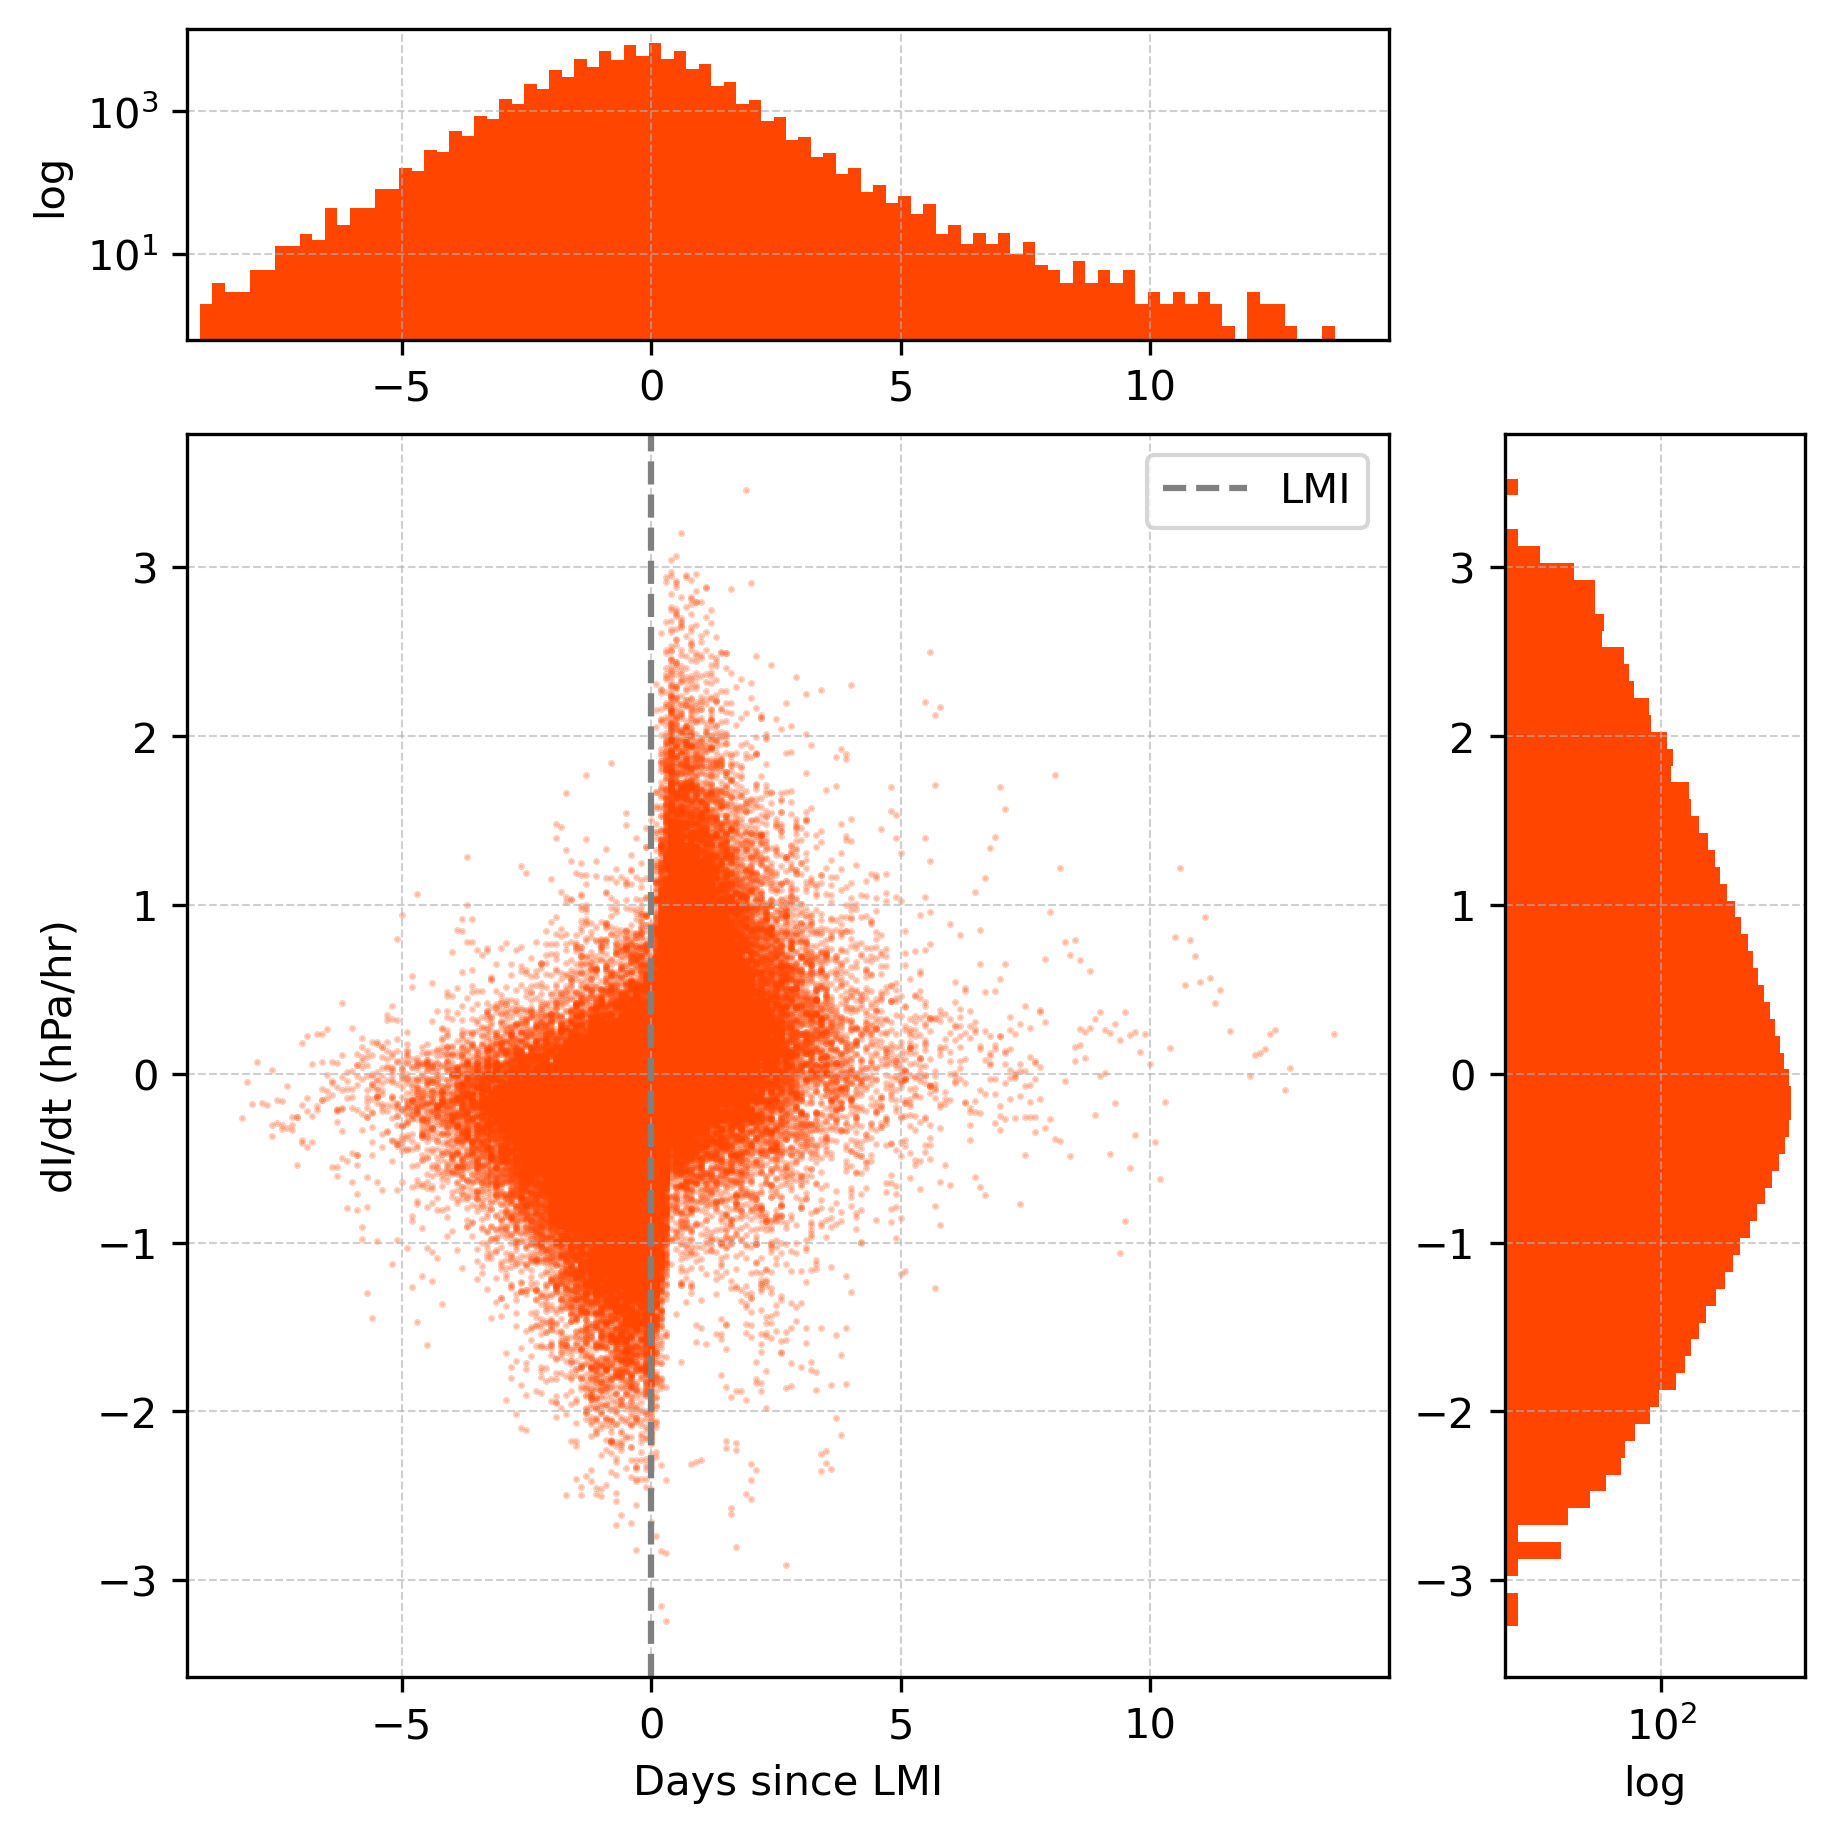

In [58]:
# scatter hist
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                              figsize=(6, 6),
                              width_ratios=(4, 1), height_ratios=(1, 4),
                              layout='constrained',
                              dpi=300)

scatter_hist(-filtered_records['hrsbeforeLMI']/60, filtered_records['slp_delta24']/24, axs['scatter'], axs['histx'], axs['histy'], 'orangered')

### overlapping histograms

ennums: ['06', '07', '08', '09', '10']
6418 unique storms found
finished collecting LMI rows
time elapsed to filter LMI rows: 48.29525446891785
finished concatenating
ennums: ['06', '07', '08', '09', '10']
6300 unique storms found
finished collecting LMI rows
time elapsed to filter LMI rows: 45.508728981018066
finished concatenating


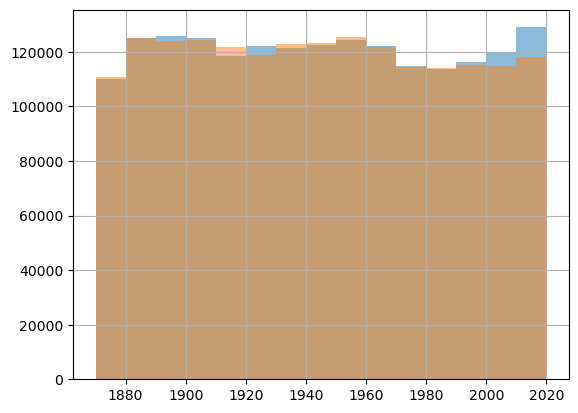

In [28]:
n = 8000
yr = (1980, 2025)
alltrack_df0, track_df0 = get_nstorms(GW=0, n=n, yearrange=yr)
alltrack_df1, track_df1 = get_nstorms(GW=1, n=n, yearrange=yr)

In [ ]:
#alltrack_df1, track_df1 = get_preloaded(GW=1)
#alltrack_df0, track_df0 = get_preloaded(GW=0)

filtered_records1 = get_filtered_records(alltrack_df1, track_df1)
filtered_records0 = get_filtered_records(alltrack_df0, track_df0)

# split by ri
ri_df1, nonri_df1 = risplit_dfs(filtered_records1)
ri_df0, nonri_df0 = risplit_dfs(filtered_records0)

# split by intensity
b0_1 = filtered_records1[filtered_records1['intensity_bin']=='b0']
b1_1 = filtered_records1[filtered_records1['intensity_bin']=='b1']
b2_1 = filtered_records1[filtered_records1['intensity_bin']=='b2']

b0_0 = filtered_records0[filtered_records0['intensity_bin']=='b0']
b1_0 = filtered_records0[filtered_records0['intensity_bin']=='b1']
b2_0 = filtered_records0[filtered_records0['intensity_bin']=='b2']

[-0.44666667 -0.83452083 -1.70208333] 
[-0.44666667 -0.84333333 -1.67319333]


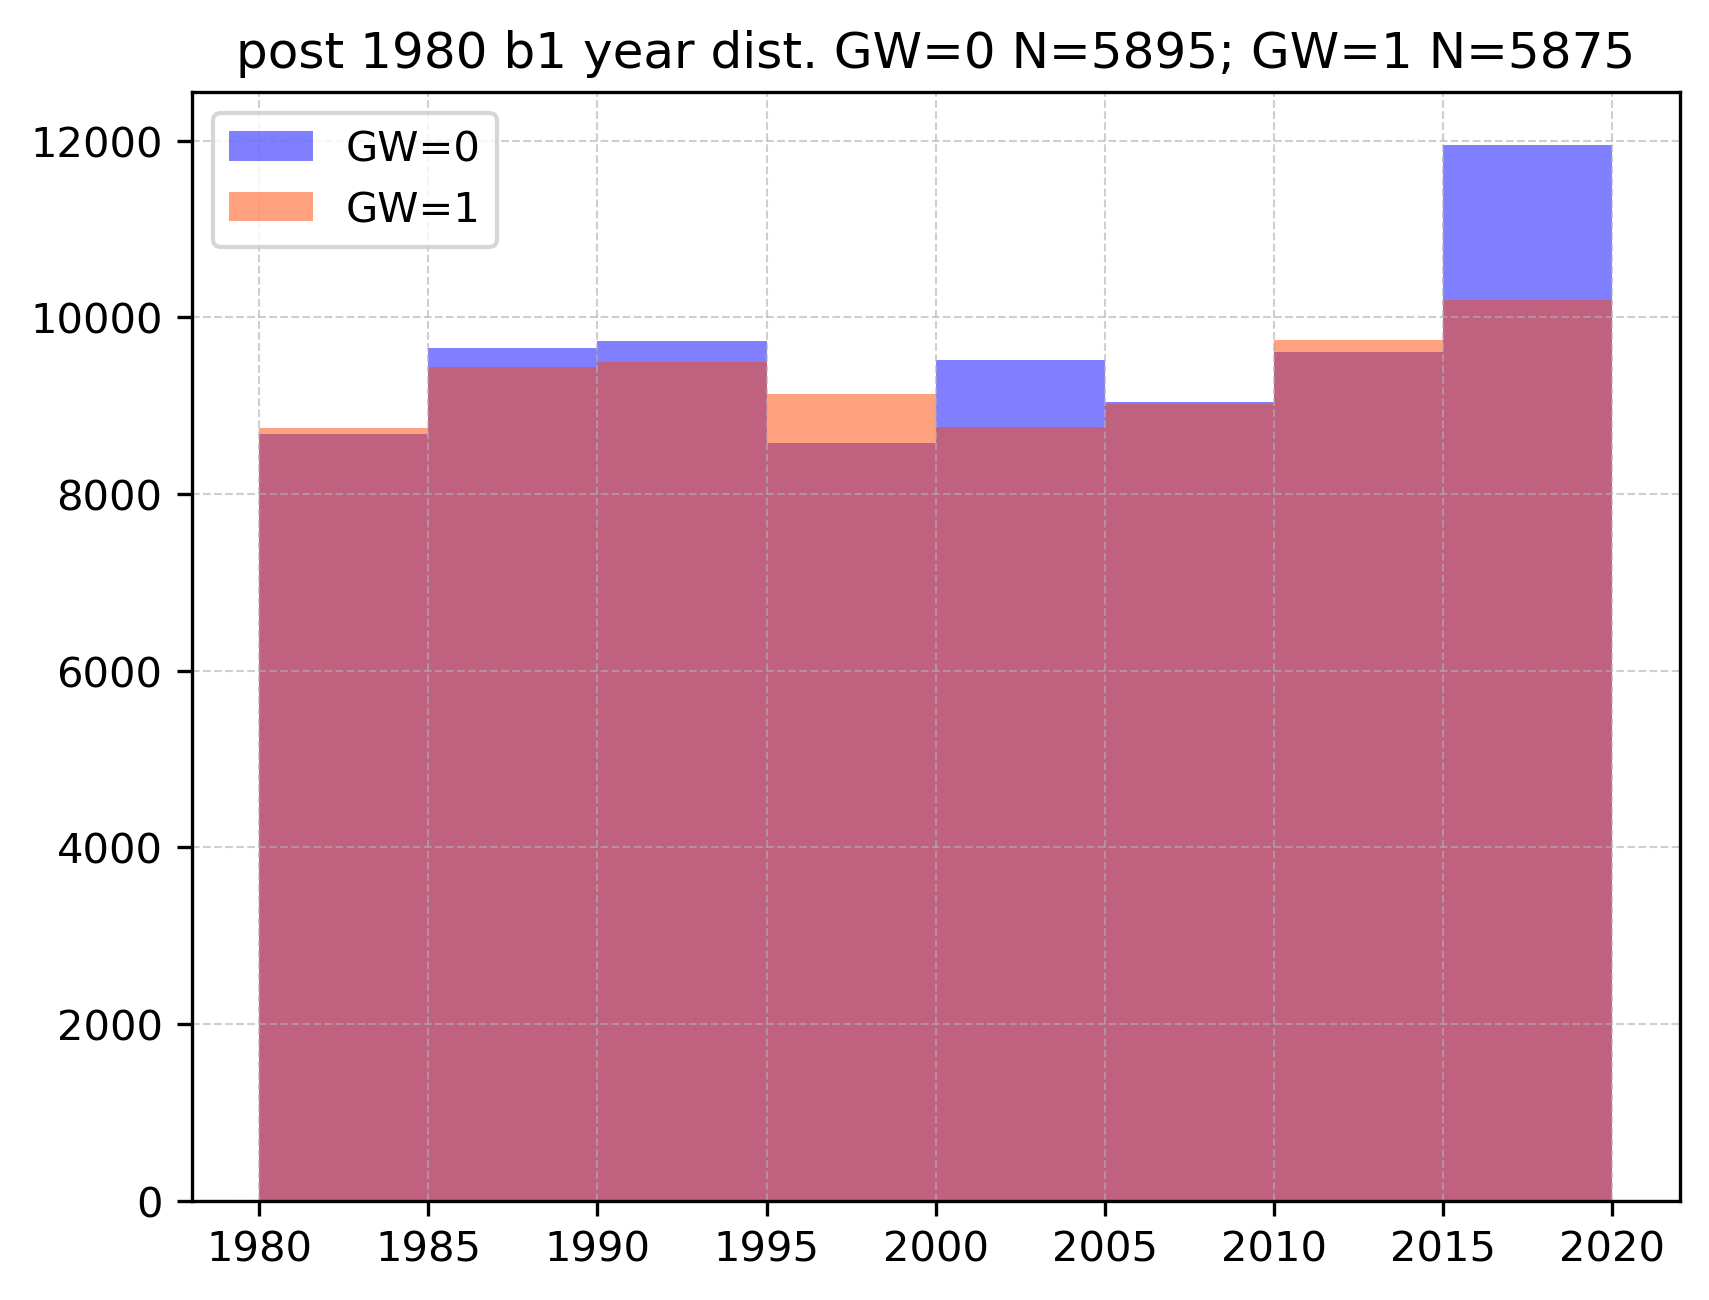

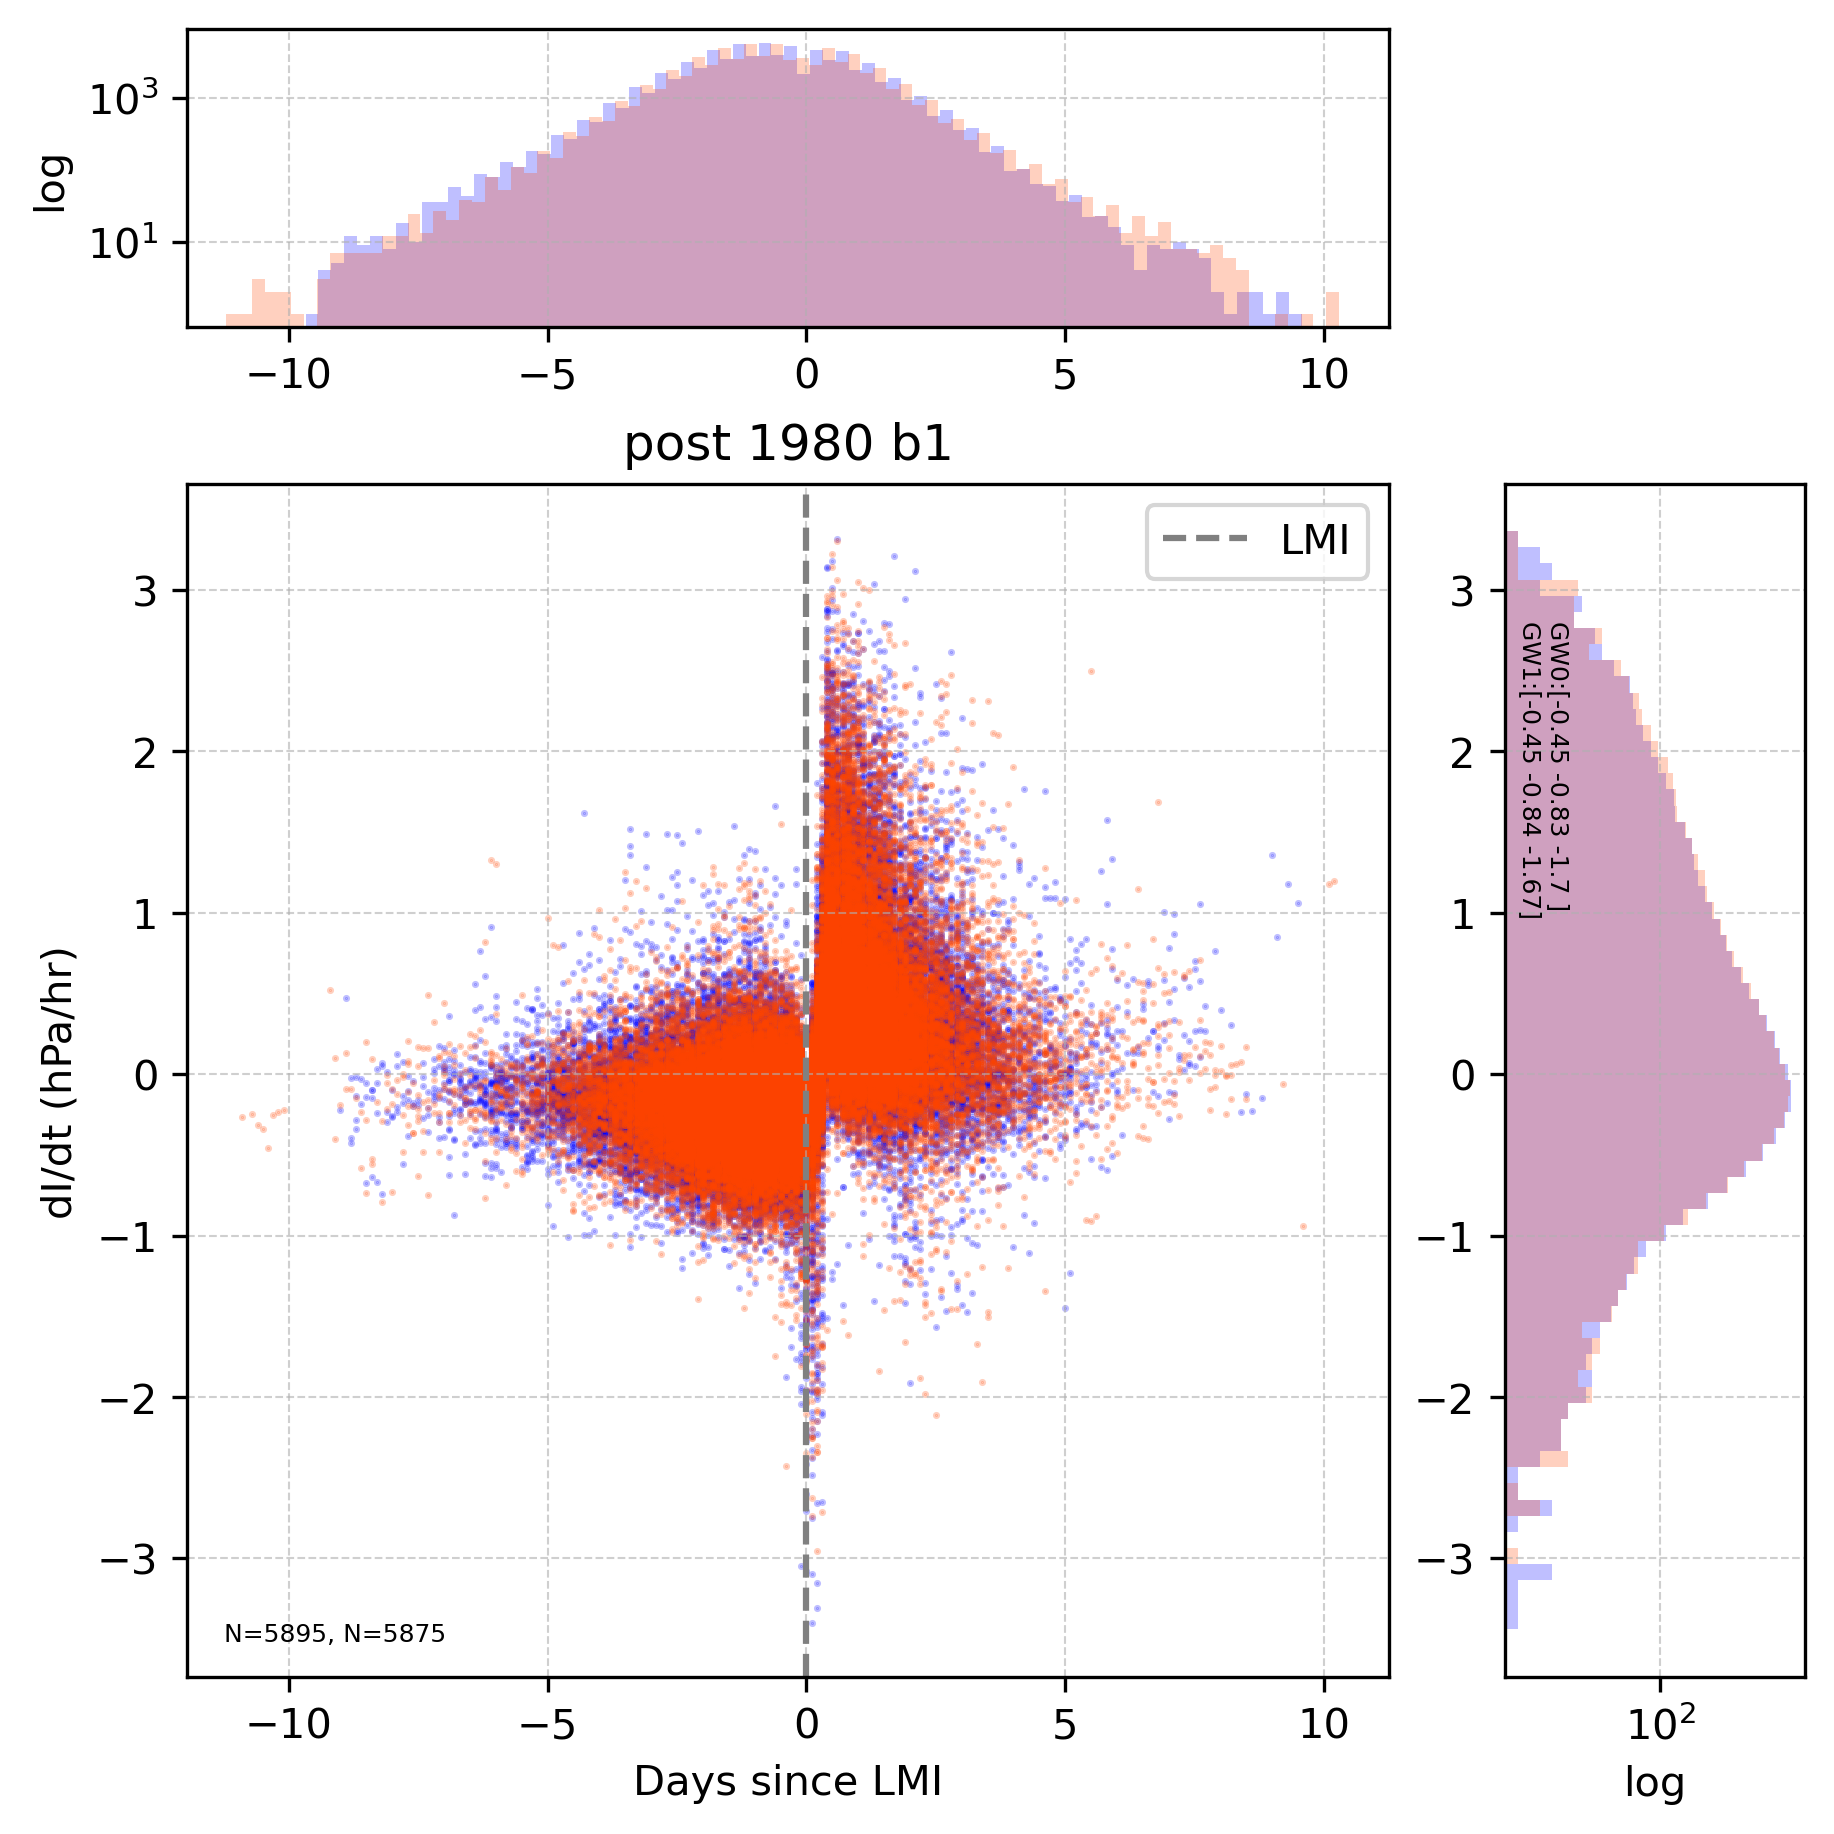

In [59]:
# intensity split
plot_year_dist(b1_0, b1_1, yr, "post 1980 b1")
plot_scatterhist(b1_0, b1_1, "post 1980 b1")

[-1.05279167 -1.83890417 -2.3525925 ] 
[-1.09666667 -1.91041667 -2.435735  ]
[-0.65620833 -1.2875     -1.84328875] 
[-0.67041667 -1.28407083 -1.8576475 ]


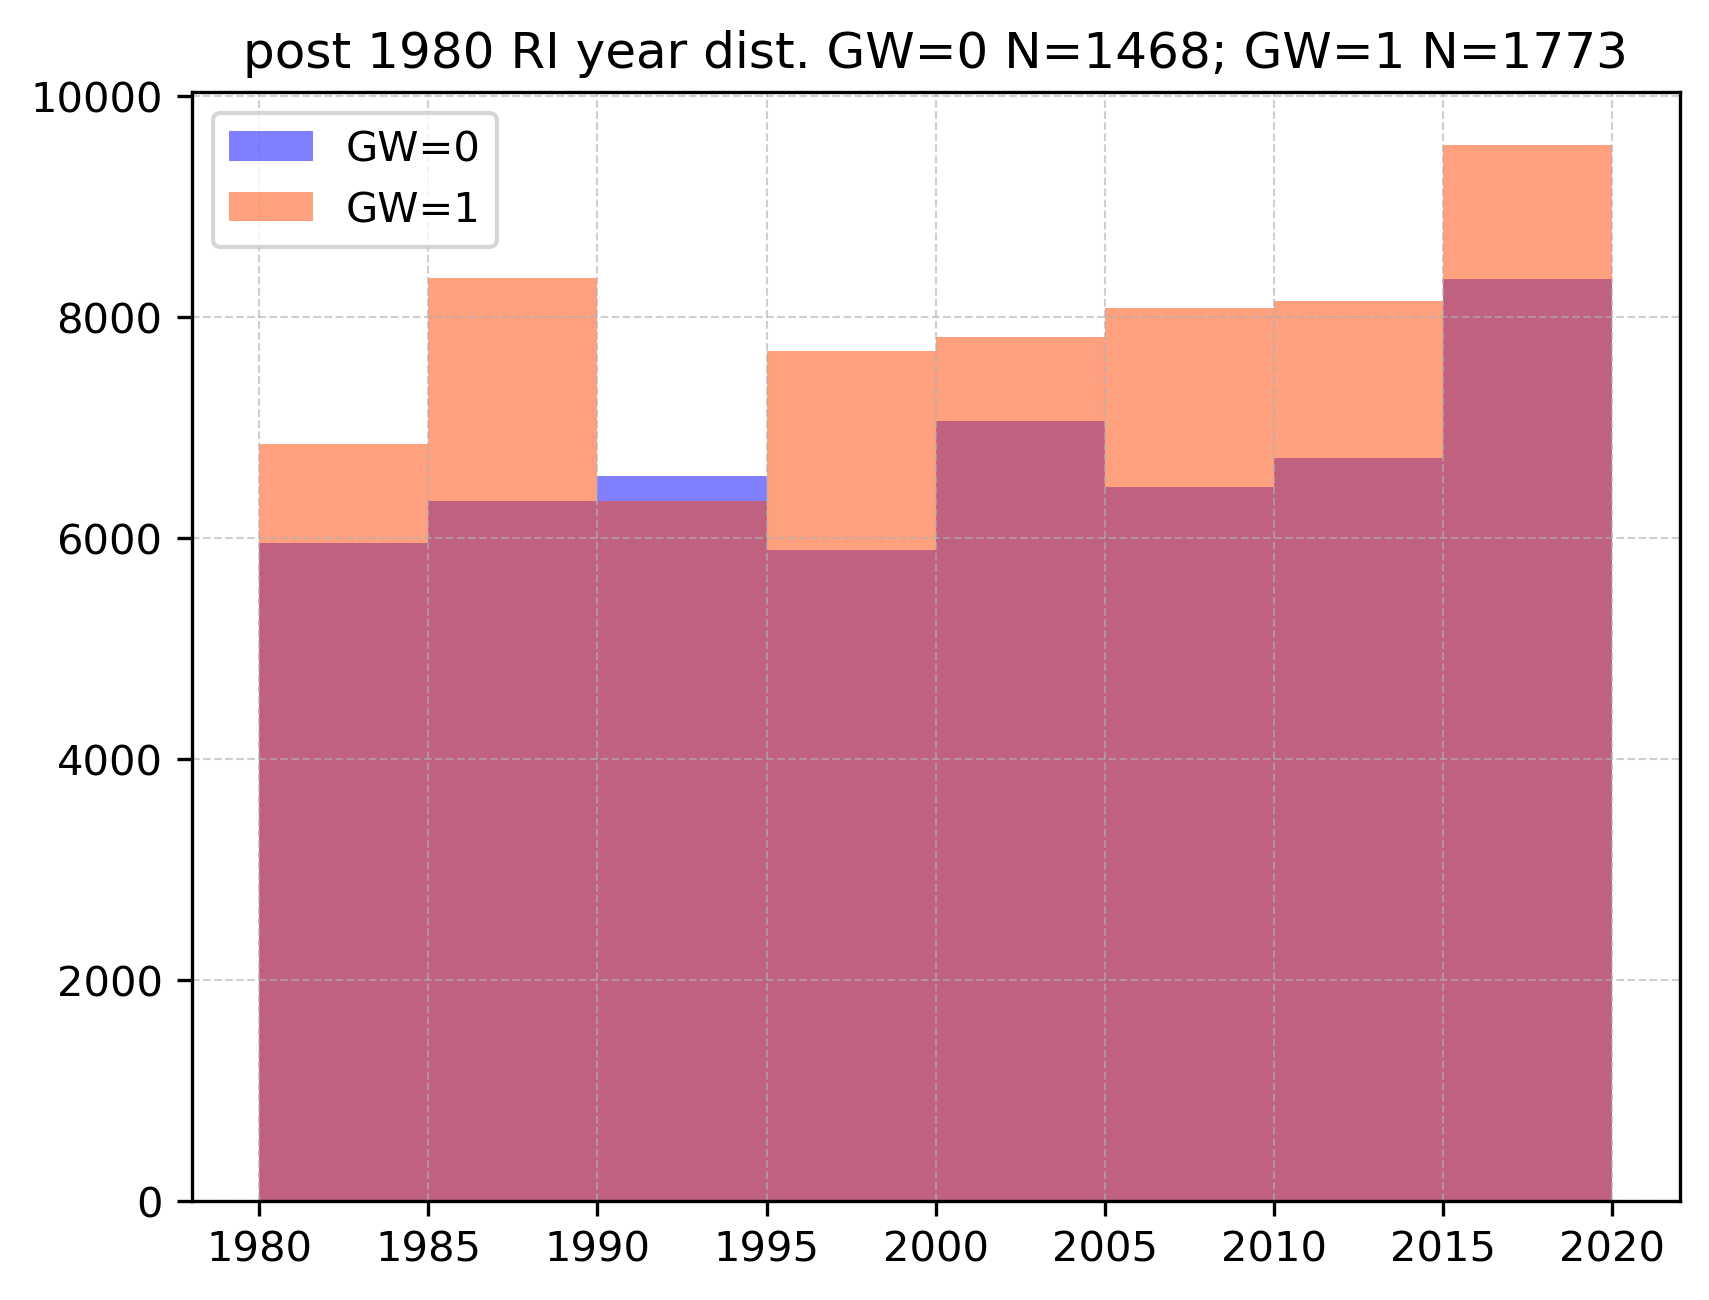

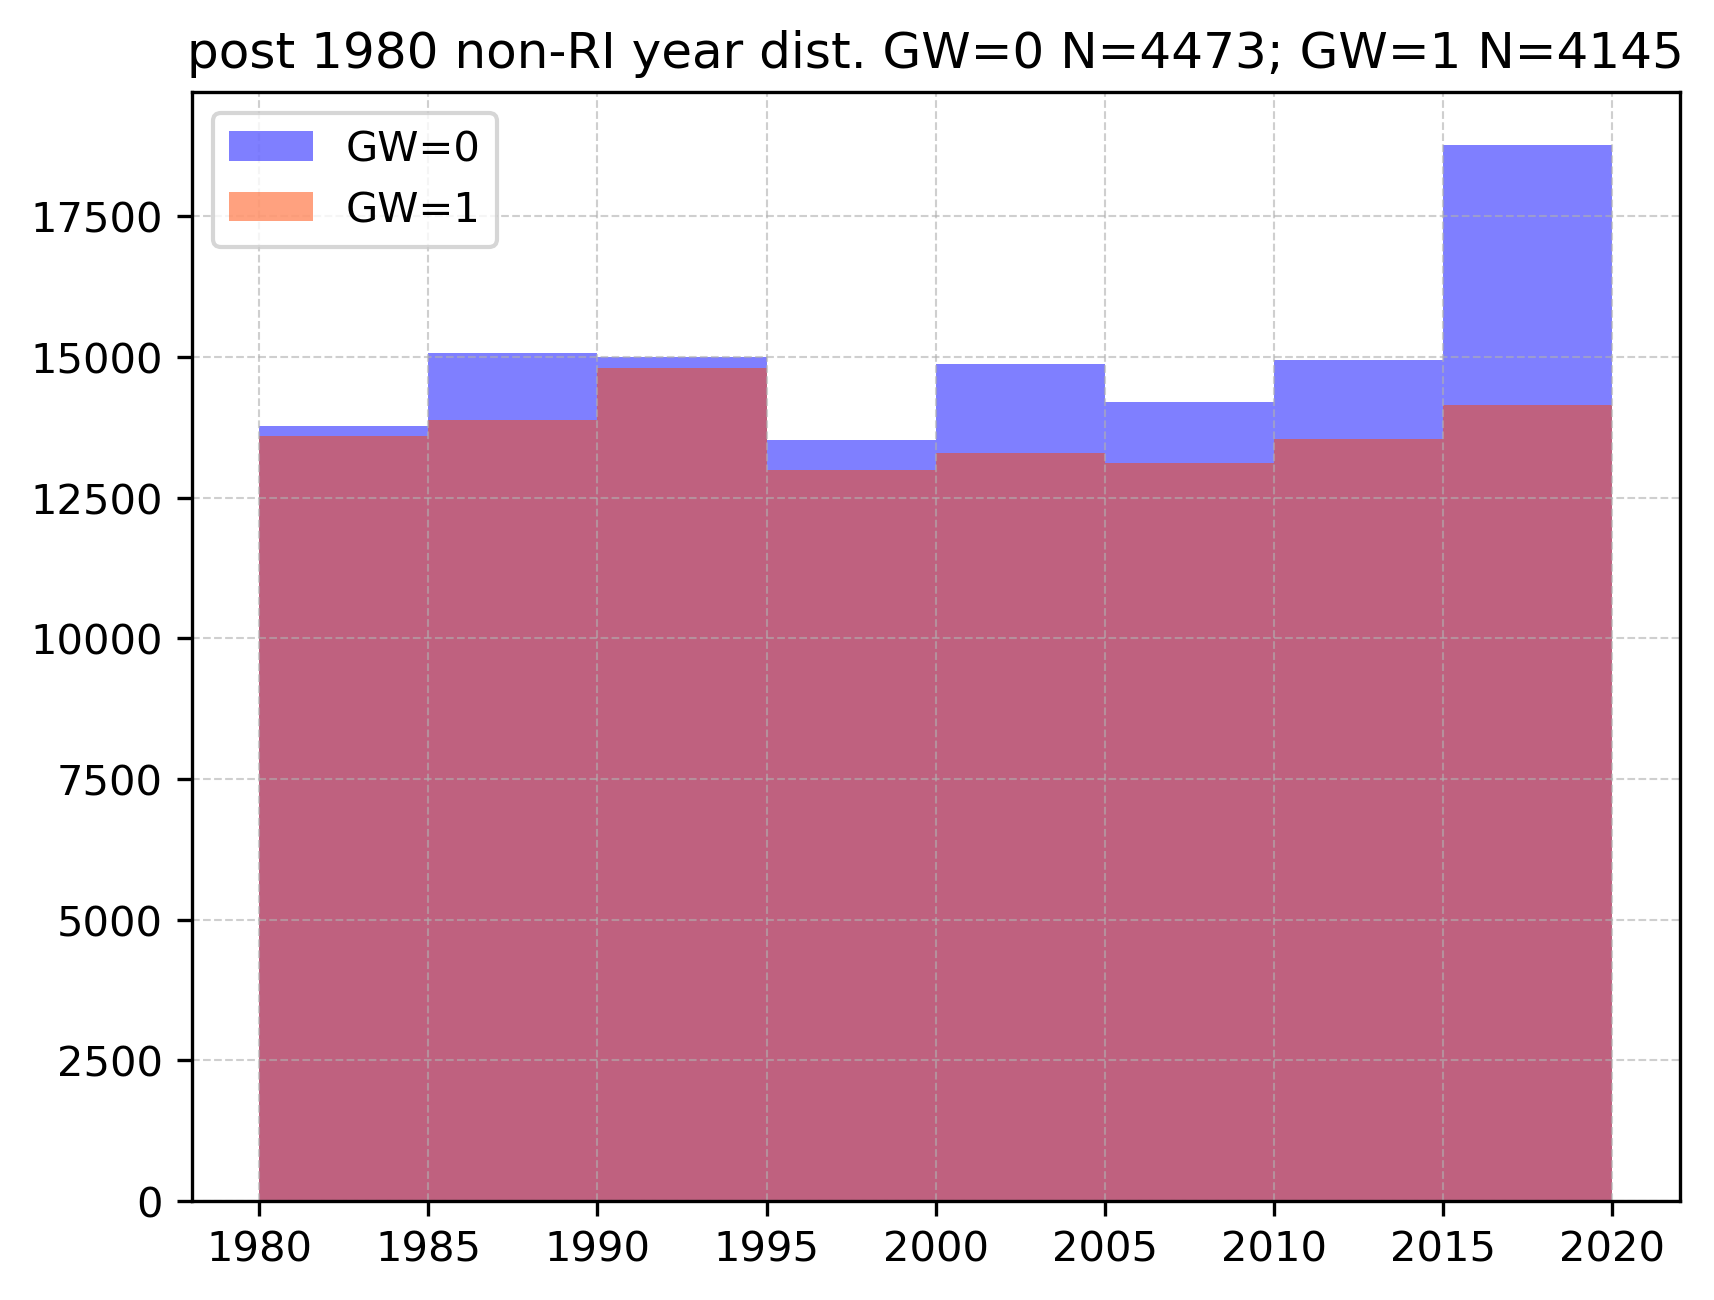

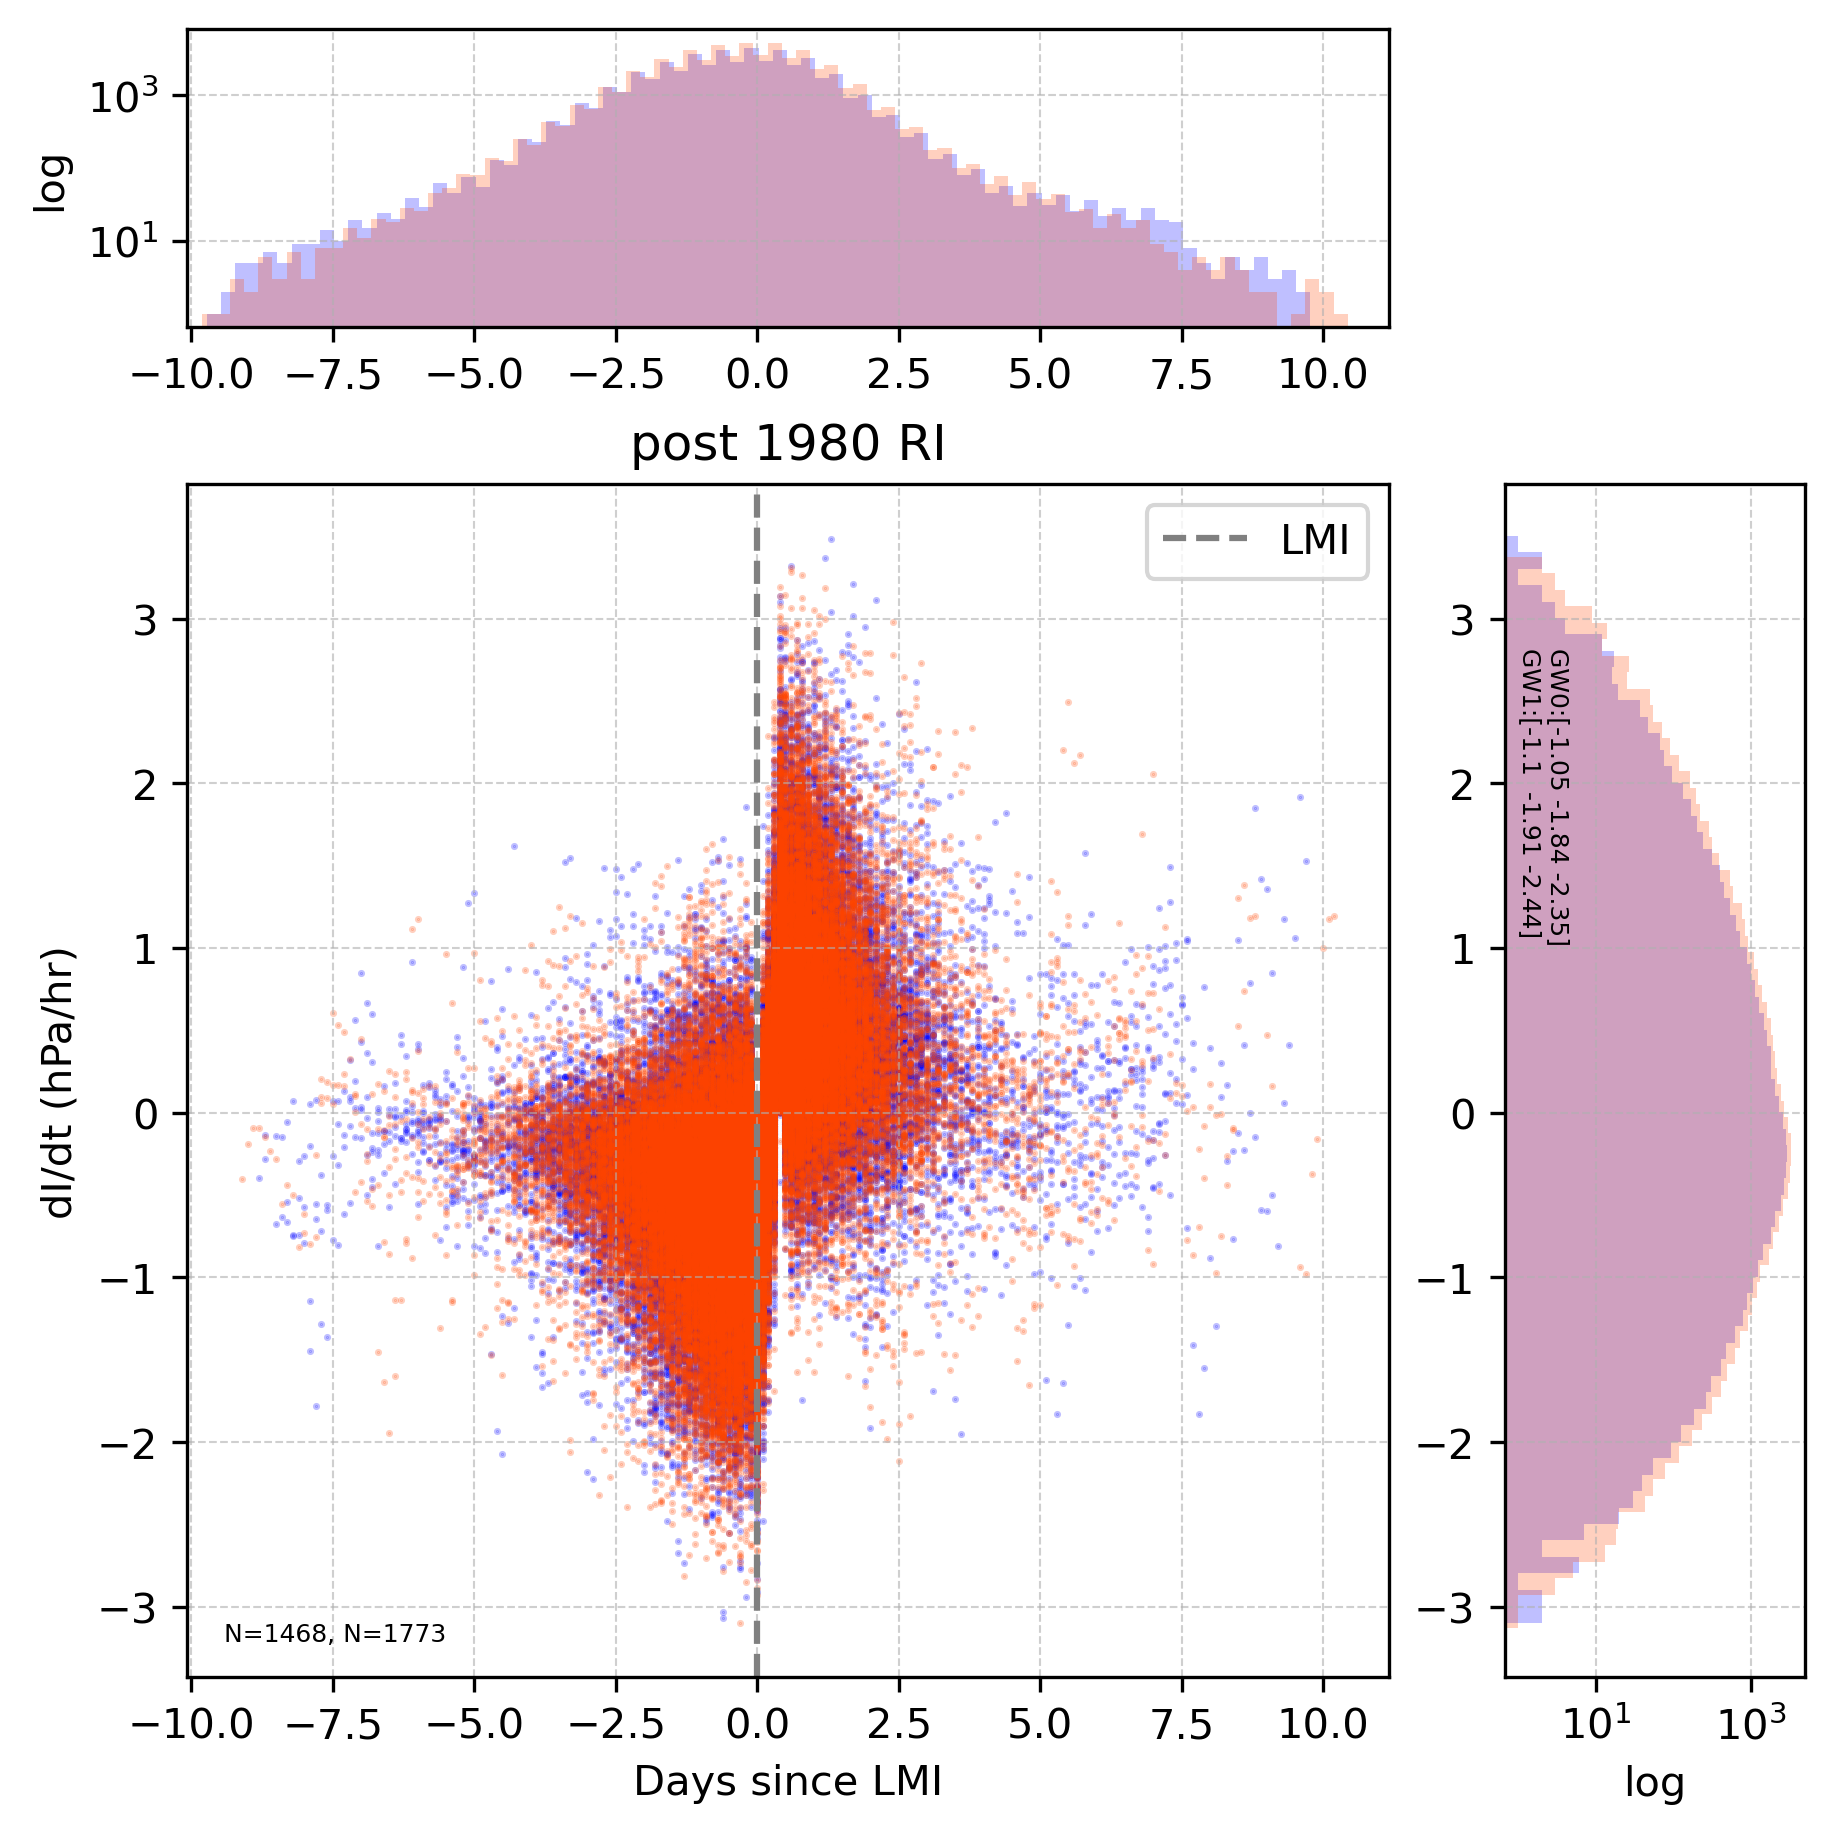

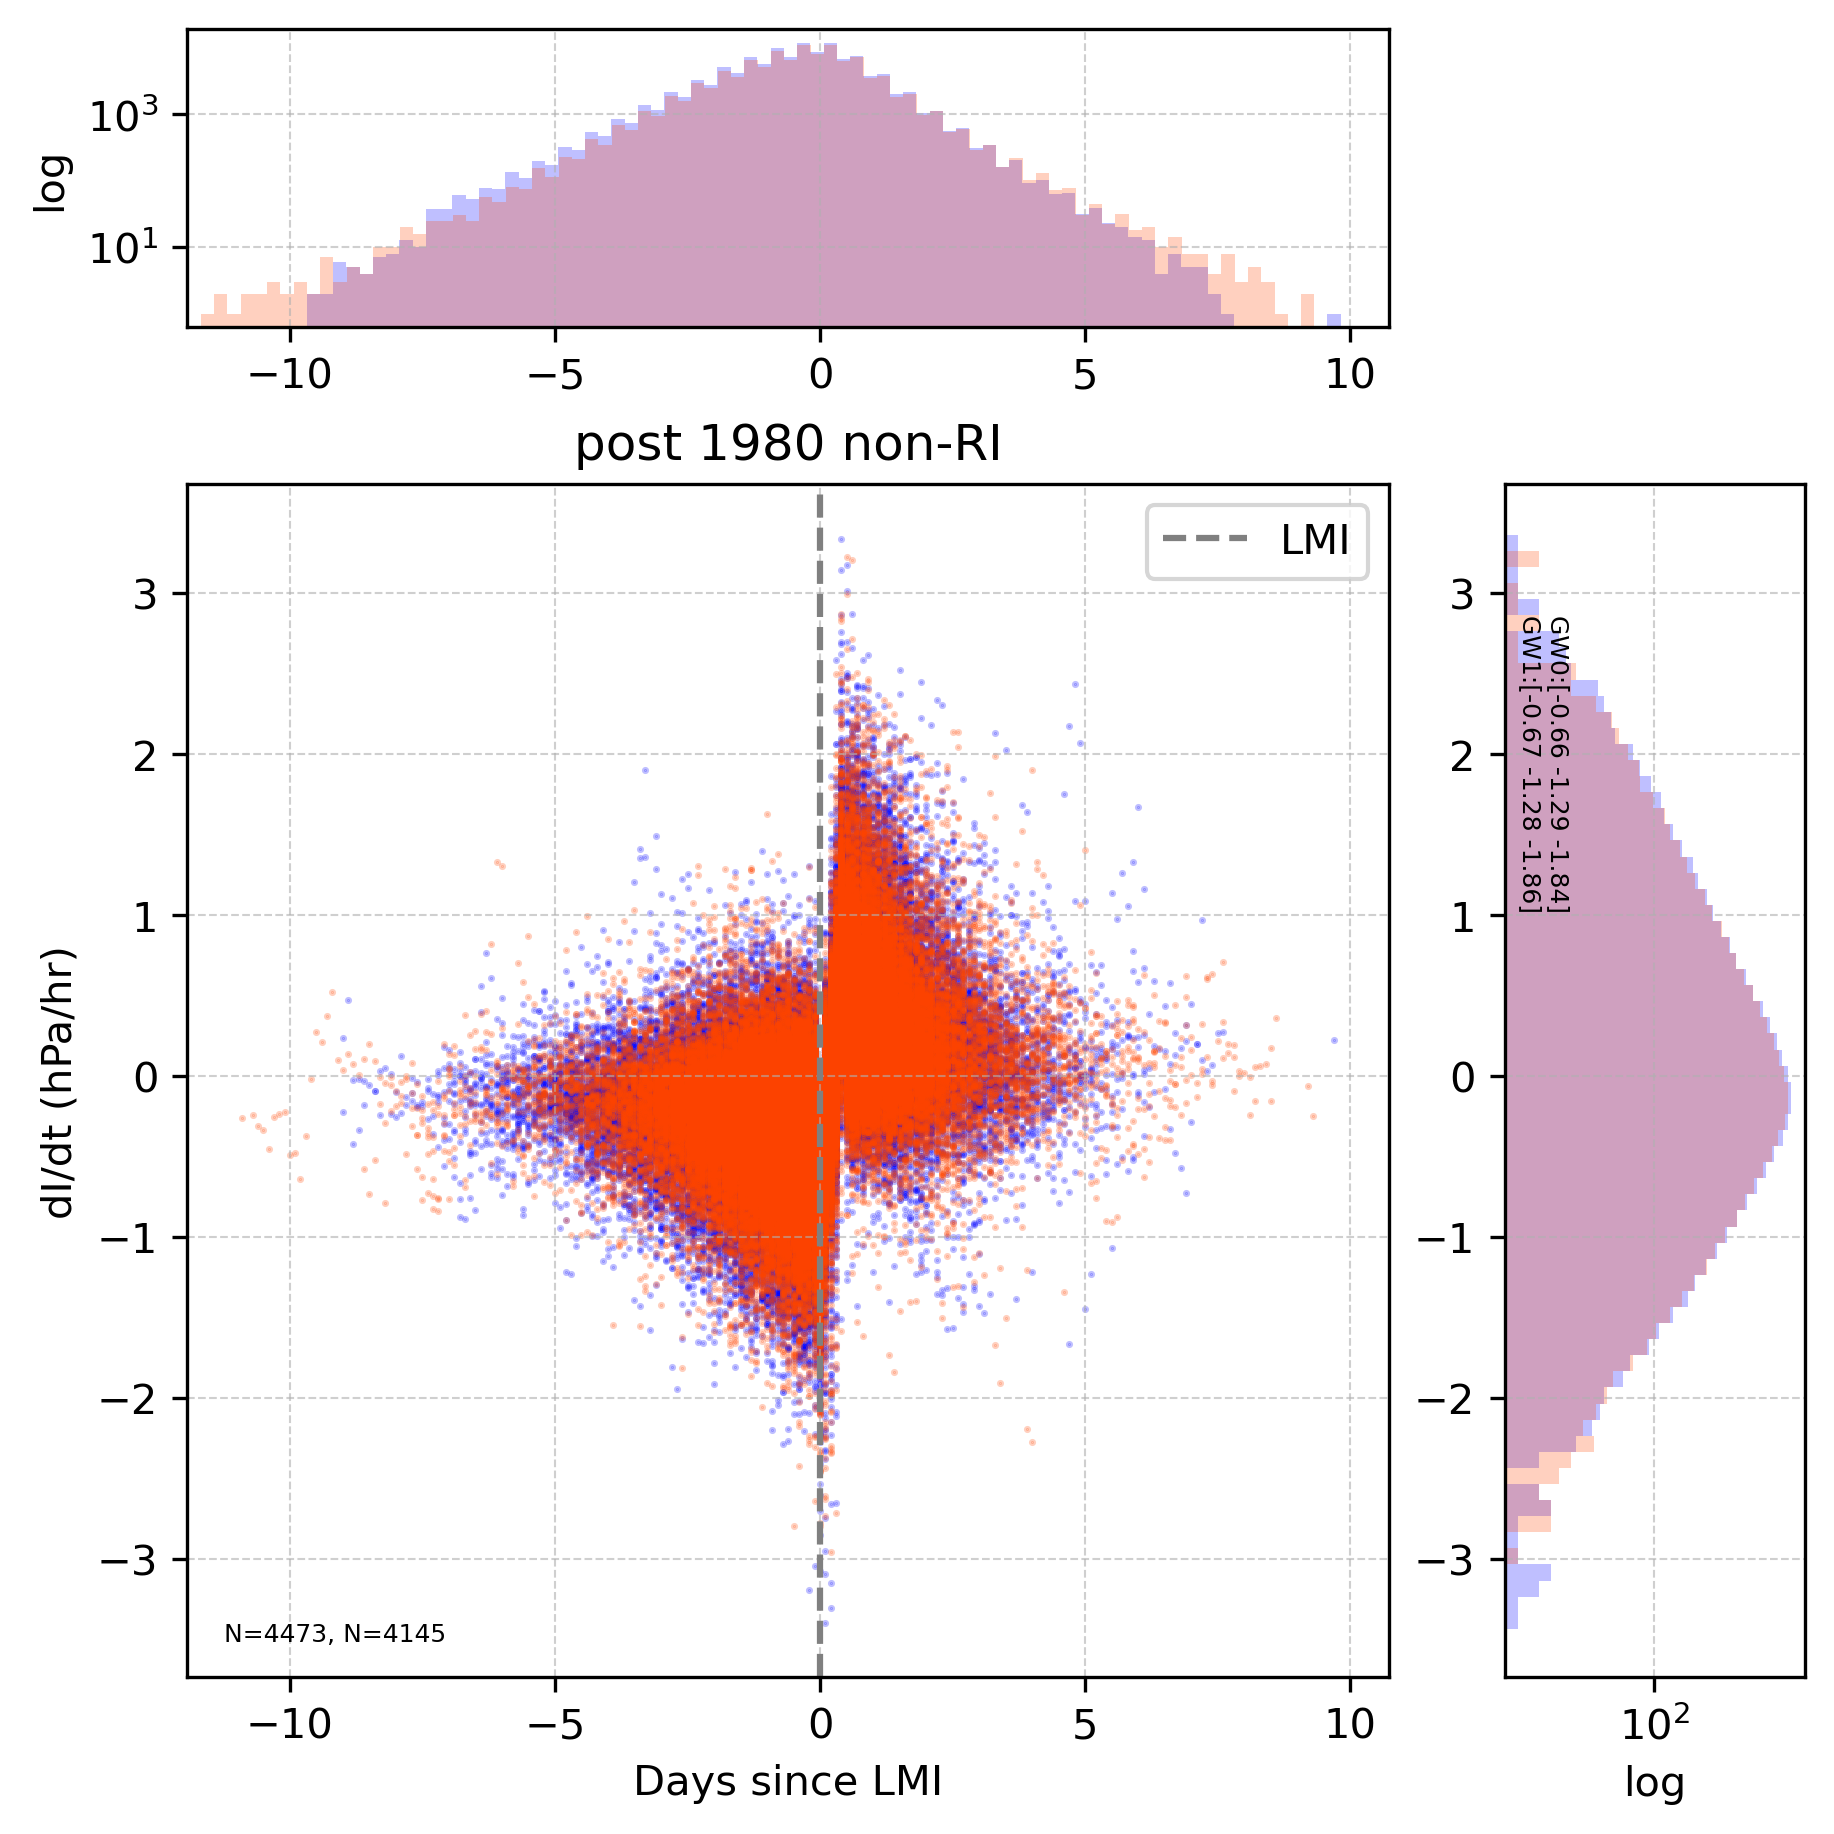

In [57]:
# ri vs. non-ri
plot_year_dist(ri_df0, ri_df1, yr, "post 1980 RI")
plot_year_dist(nonri_df0, nonri_df1, yr, "post 1980 non-RI")

plot_scatterhist(ri_df0, ri_df1, "post 1980 RI")
plot_scatterhist(nonri_df0, nonri_df1, "post 1980 non-RI")

## Plot composite

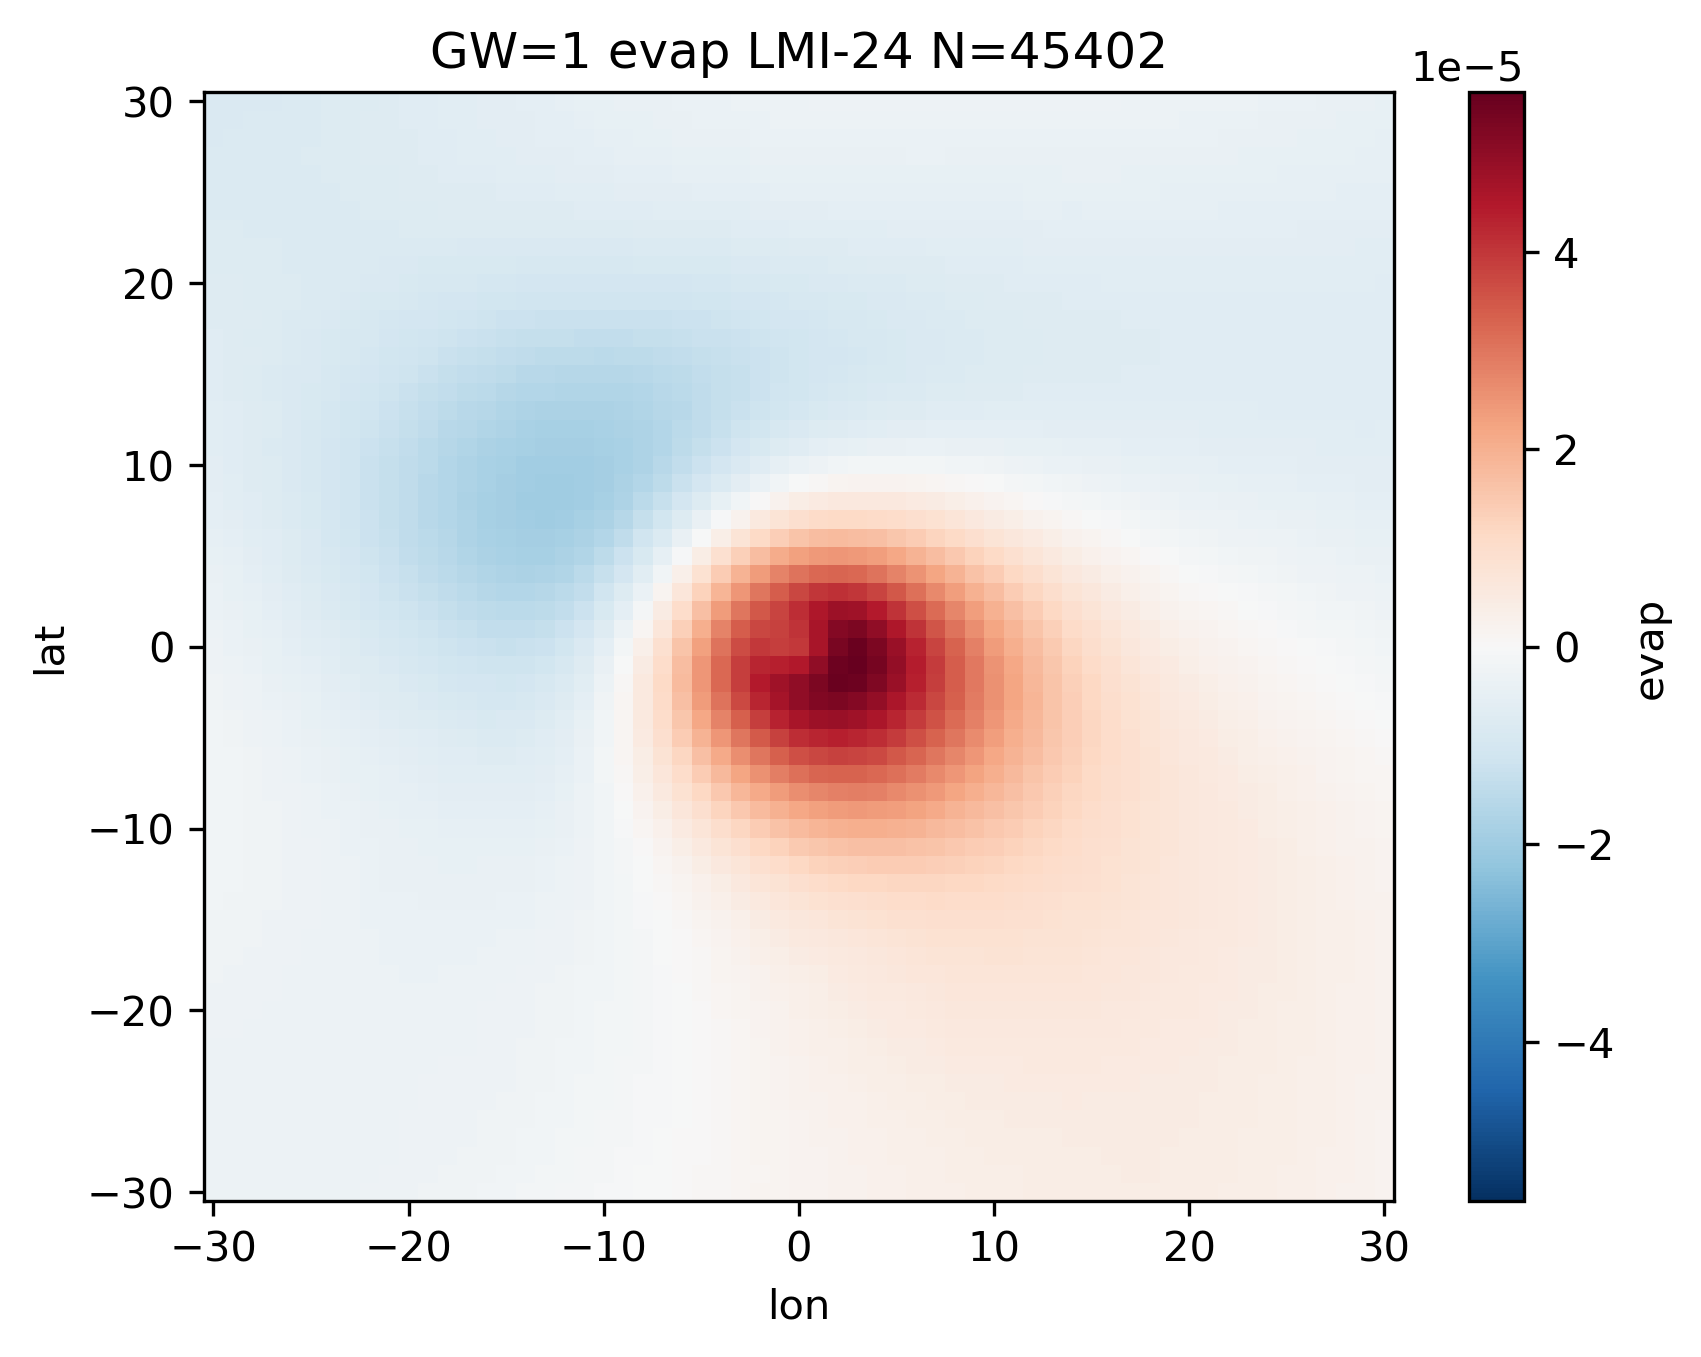

In [24]:
# raw composite for one model
plotname = f"GW{GW}_{param}_LMI-24.png"
filename = f"GW{GW}{param}@LMI-24.nc"
netcdf = xr.open_dataset(filename).load()

# plot
fig, ax = plt.subplots(dpi=300)
netcdf.mean(dim='storm_id')[param].plot(ax=ax)
ax.set_title(f"GW={GW} {param} LMI-24 N={len(netcdf['storm_id'])}")
plt.savefig(plotname)

### GW1-GW0

In [22]:
param = 'evap'

Text(0.5, 1.0, 'GW1-GW0 evap LMI N=48624')

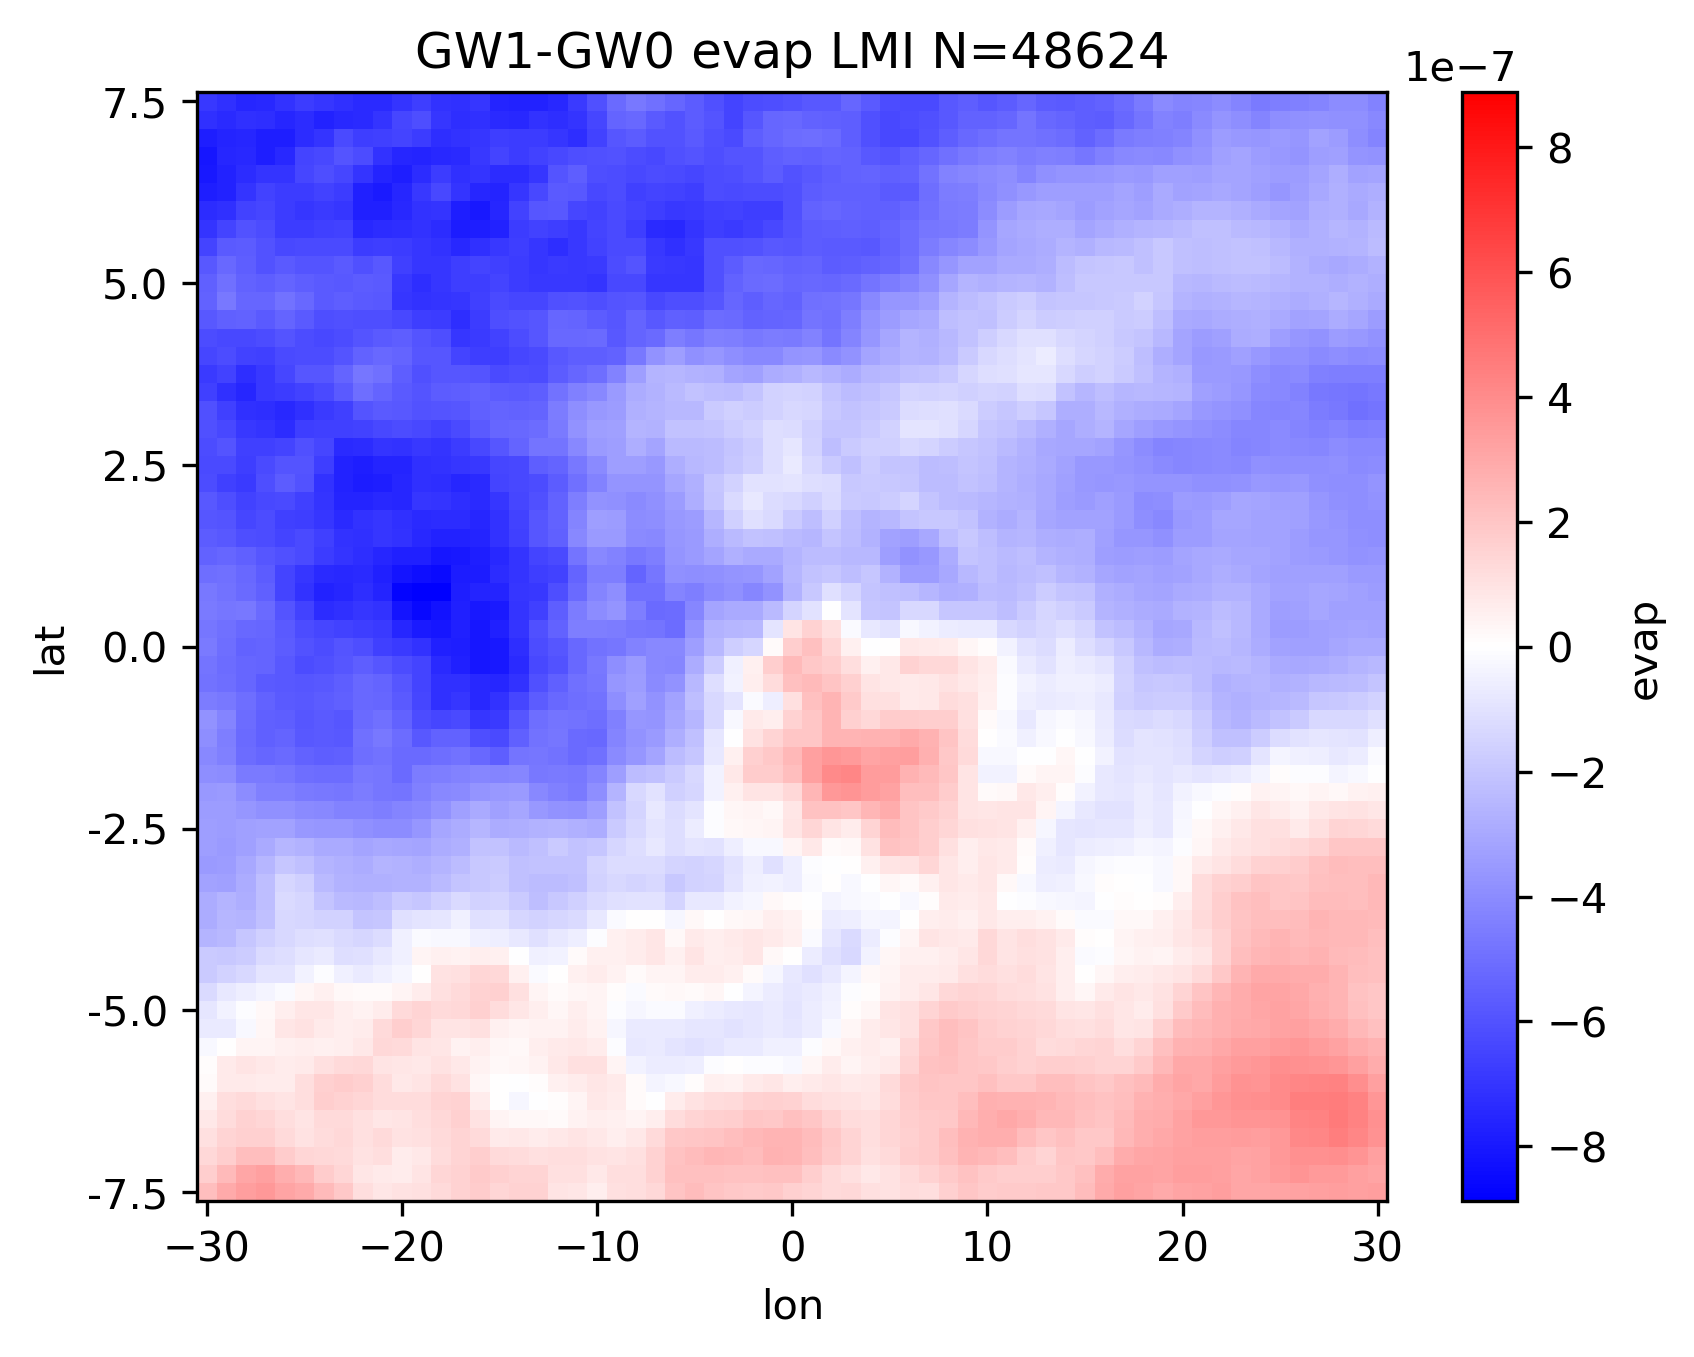

In [23]:
# raw GW1-GW0 differential composite
netcdf = xr.open_dataset(f"GW0{param}@LMI.nc").load()
netcdf1 = xr.open_dataset(f"GW1{param}@LMI.nc").load()

fig, ax = plt.subplots(dpi=300)
(netcdf1.mean(dim='storm_id')[param]-netcdf.mean(dim='storm_id')[param]).plot(ax=ax, cmap='bwr')
ax.set_yticklabels(np.arange(-40,50,10)/4)
ax.set_title(f"GW1-GW0 {param} LMI N={len(netcdf['storm_id'])}")
#plt.savefig(f"{param}Diff_LMI-24.png")

#### pre vs. post 1950

Text(0.5, 1.0, 'GW1-GW0 q500 LMI >1950 N=22117')

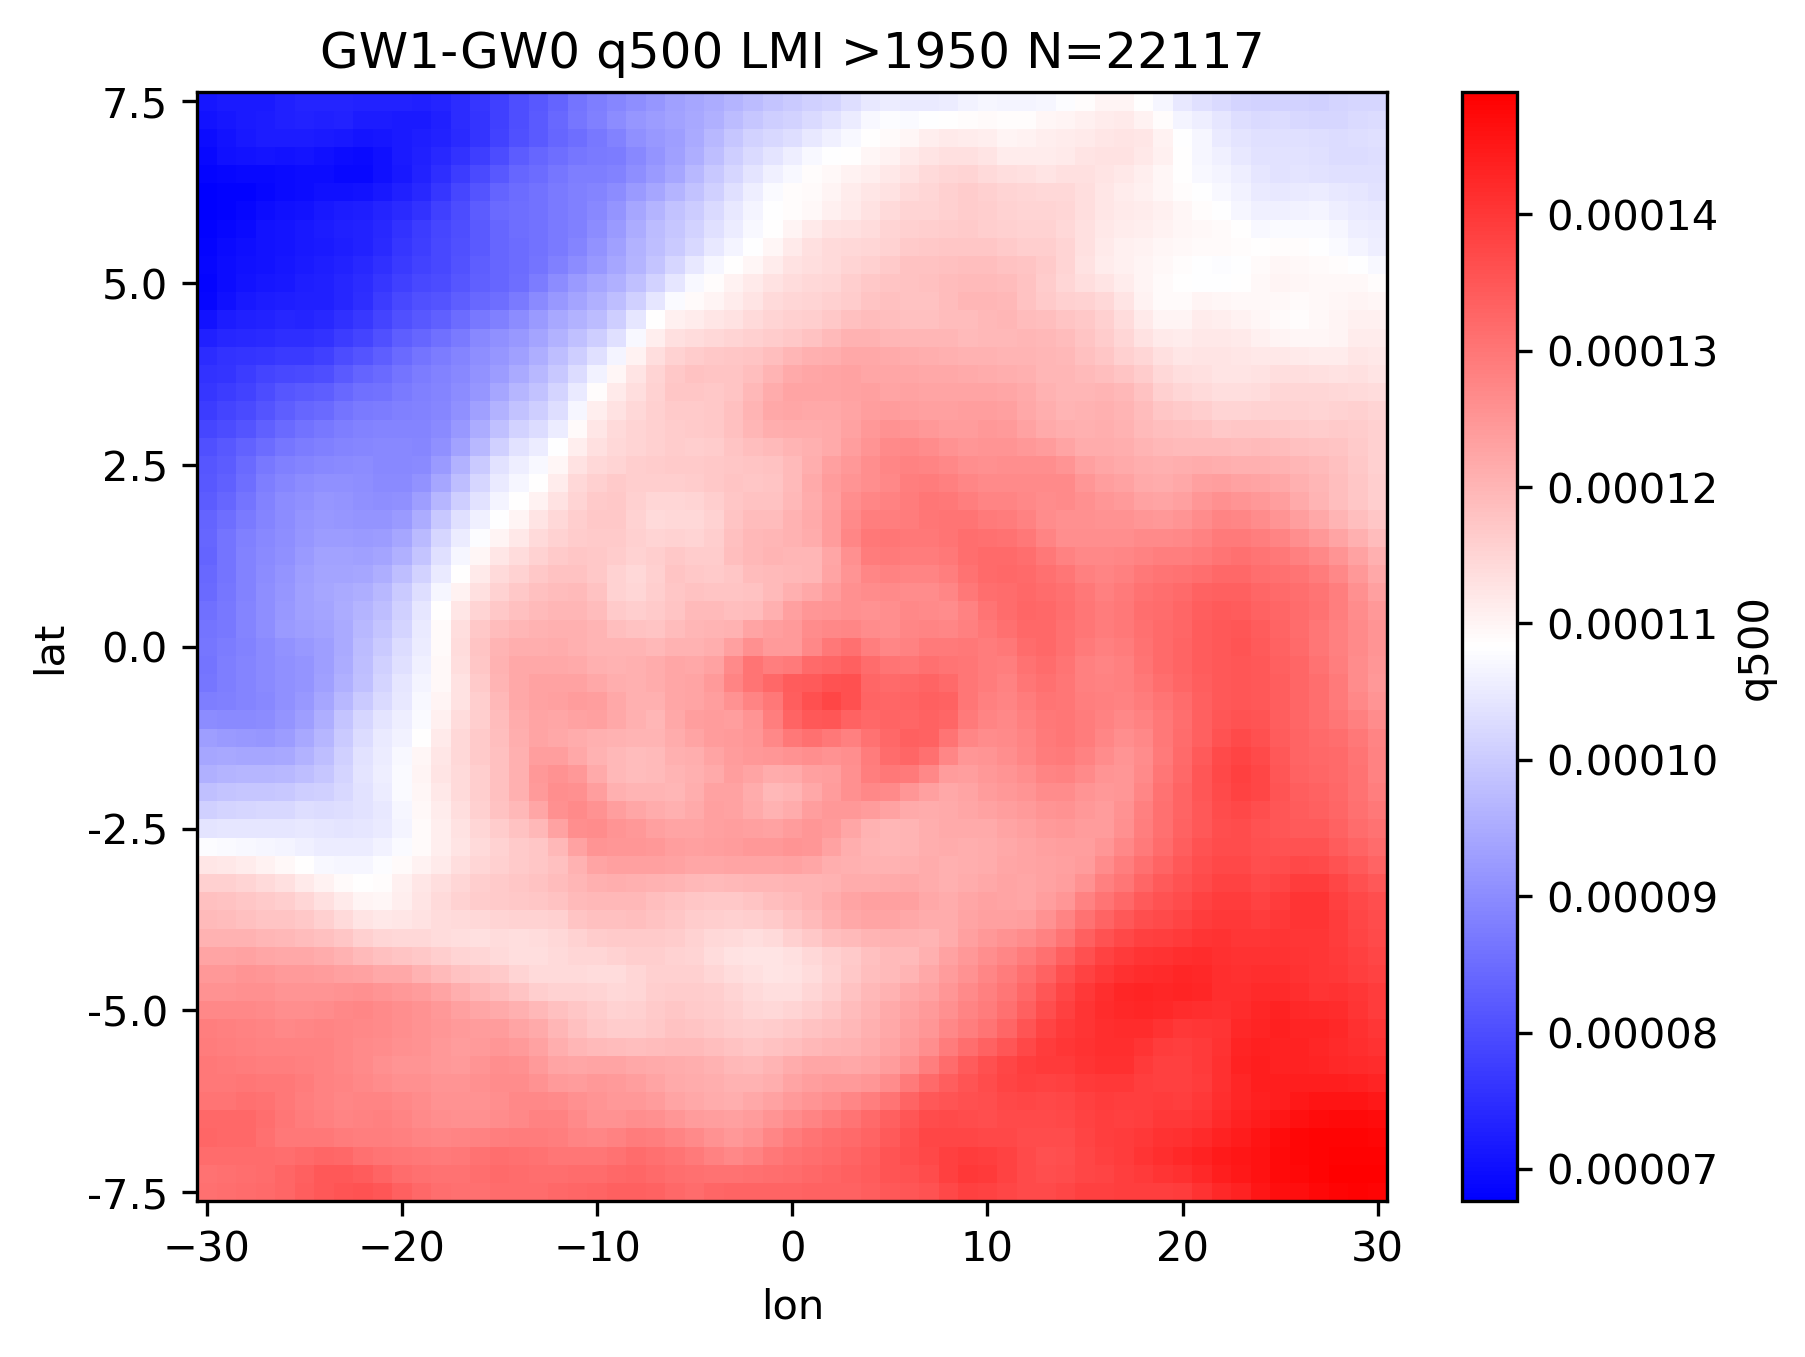

In [92]:
# select time range for GW1-GW0 differential composite
filtered = netcdf.where(netcdf['time'].dt.year > 1950, drop=True)
filtered1 = netcdf1.where(netcdf1['time'].dt.year > 1950, drop=True)

fig, ax = plt.subplots(dpi=300)
(filtered1.mean(dim='storm_id')[param]-filtered.mean(dim='storm_id')[param]).plot(ax=ax, cmap='bwr')
ax.set_yticklabels(np.arange(-40,50,10)/4)
ax.set_title(f"GW1-GW0 {param} LMI >1950 N={len(filtered1['storm_id'])}")
#plt.savefig(f"{param}Diff_LMI-24_post1950.png")

Text(0.5, 1.0, 'GW1-GW0 q500 LMI <1950 N=26165')

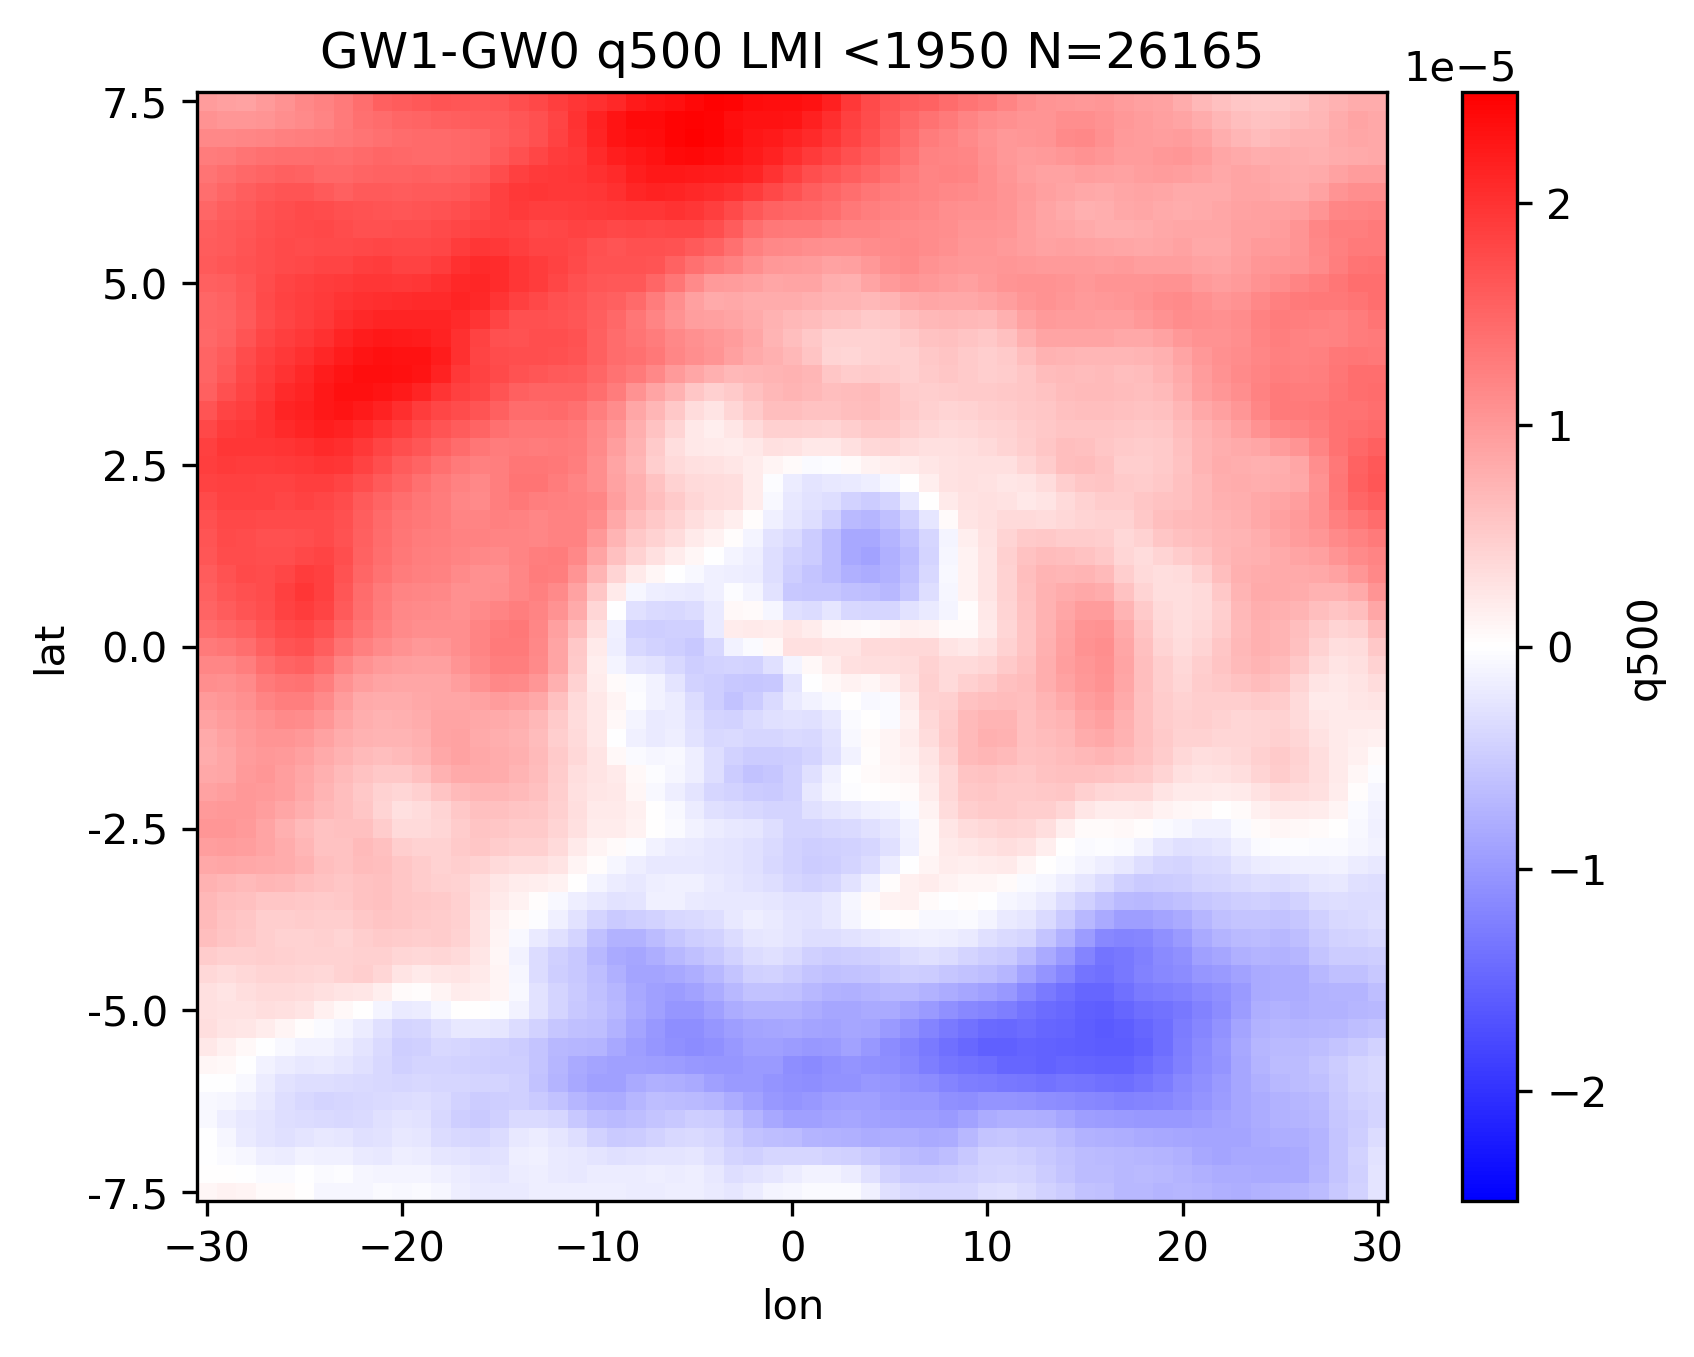

In [93]:
# select time range for GW1-GW0 differential composite
filtered = netcdf.where(netcdf['time'].dt.year < 1950, drop=True)
filtered1 = netcdf1.where(netcdf1['time'].dt.year < 1950, drop=True)

fig, ax = plt.subplots(dpi=300)
(filtered1.mean(dim='storm_id')[param]-filtered.mean(dim='storm_id')[param]).plot(ax=ax, cmap='bwr')
ax.set_yticklabels(np.arange(-40,50,10)/4)
ax.set_title(f"GW1-GW0 {param} LMI <1950 N={len(filtered1['storm_id'])}")
#plt.savefig(f"{param}Diff_LMI-24_pre1950.png")

### intensity split

In [ ]:
# windspeed category dictionary
windcategories = {
    'TS' : (17, 33),
    'Cat 1': (33, 42.9),
    'Cat 2': (42.9, 49.6),
    'Cat 3': (49.6, 58.1),
    'Cat 4': (58.1, 70.2),
    'Cat 5': (70.2, 200)
}

In [ ]:
# raw GW1-GW0 differential composite
intensity = windcategories['Cat 2']
param = 'WVP'

netcdf = xr.open_dataset(f"GW0{param}@LMI.nc").load()
netcdf1 = xr.open_dataset(f"GW1{param}@LMI.nc").load()

# select time range for GW1-GW0 differential composite
filtered = netcdf.where((netcdf['max_wind'] >= intensity[0]) & (netcdf['max_wind'] < intensity[1]), drop=True)
filtered1 = netcdf1.where((netcdf1['max_wind'] >= intensity[0]) & (netcdf1['max_wind'] < intensity[1]), drop=True)

fig, ax = plt.subplots(dpi=300)
(filtered1.mean(dim='storm_id')[param]-filtered.mean(dim='storm_id')[param]).plot(ax=ax, cmap='bwr')
ax.set_title(f"GW1-GW0 {param} LMI <1950 N={len(filtered1['storm_id'])}")
plt.savefig(f"{param}Diff_LMI_pre1950_18712021.png")

### basin-level split

### TC density

In [ ]:
# get experiment names and dictionary of xarrays
from pathlib import Path

experiment_path = 'EXPERIMENT_PATH'

experiments = []
if GW == 1:
    target_files = list(Path(experiment_path).glob('*DUMMY_STRING*'))
    for file in target_files:
        experiments.append(str(file)[-29:])
elif GW == 0:
    target_files = list(Path(experiment_path).glob('*DUMMY_STRING*'))
    for file in target_files:
        experiments.append(str(file)[-39:])

print(experiments)

['amipHadISSTlong_chancorr-en04', 'amipHadISSTlong_chancorr-en09', 'amipHadISSTlong_chancorr-en08', 'amipHadISSTlong_chancorr-en03', 'amipHadISSTlong_chancorr-en01', 'amipHadISSTlong_chancorr-en07', 'amipHadISSTlong_chancorr-en10', 'amipHadISSTlong_chancorr-en06', 'amipHadISSTlong_chancorr-en02', 'amipHadISSTlong_chancorr-en05']


In [36]:
# get mean of all xarrays in dictionary
xrlist = []

# experiments already gathered in prev cell
model_name = 'AM2.5C360'
year_range = [1871, 2019]
#PIx_da = concat_da.mean(dim="time")
experiment_name = experiments
    #en06-en10 (experiments[1-2, 5-7]) do not work for some reason -> all GW = 0

# return dictionary[model_name][experiment_name] of TC density
TCdensity = TC_analysis.TC_density(model_names=model_name, experiment_names=experiment_name, year_range=year_range)

listof_TCdensities = []

# combine all ensemble density outputs
for exp in experiment_name:
    TMP = TCdensity[model_name][exp]
    
    # convert dictionary to dataframe with same dims for xarray
    TCdensity_xr = xr.DataArray(data=TMP.values,
                                   coords={'lat': (['lat'], TMP.index),
                                           'lon': (['lon'], TMP.columns)},
                                   dims=['lat', 'lon'])
    
    #TCdensity_xr = TCdensity_xr.sel(lat=slice(PIx_da.lat.min(), PIx_da.lat.max()))
    # Interpolate to GCM native resolution
    #TCdensity_xr = TCdensity_xr.interp(lon=PIx_da.lon, lat=PIx_da.lat).fillna(0)
    listof_TCdensities.append(TCdensity_xr) # append xarray to list for concatenation

TCdensity_xr = xr.concat(listof_TCdensities, dim='time')

normDensity = ((TCdensity_xr - TCdensity_xr.min()) / (TCdensity_xr.max() - TCdensity_xr.min())) #normalize (0,1) for matrix multiplication
normDensity1 = normDensity+1 #normalize (1,2) for matrix multiplication

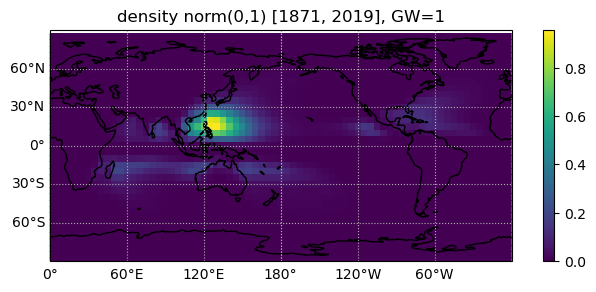

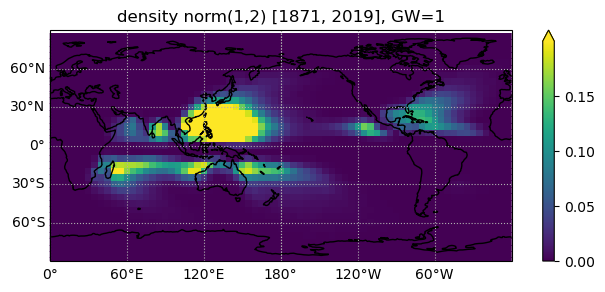

In [37]:
# plots
plot_xrda(normDensity.mean(dim="time"), f"density norm(0,1) {year_range}, GW={GW}", 0)
plot_xrda(normDensity.mean(dim="time"), f"density norm(1,2) {year_range}, GW={GW}", 1)